# Imports

In [1]:
# SPN Imports
from spn.structure.leaves.parametric.Parametric import Categorical, Gaussian
from spn.structure.Base import Product, Sum, assign_ids, rebuild_scopes_bottom_up, Leaf, get_nodes_by_type
from spn.algorithms.Inference import log_likelihood, likelihood
from spn.algorithms.LearningWrappers import learn_parametric
from spn.algorithms.EM import EM_optimization as EM
import spn.algorithms.Inference as spninf
from spn.io.Graphics import plot_spn
from spn.structure.Base import Context
from spn.structure.StatisticalTypes import MetaType

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pgmpy.inference import VariableElimination
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
import itertools
import pandas as pd
import numpy as np
import time
from scipy import stats
from scipy.stats import skew, kurtosis
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import trange
from scipy.stats import norm, gaussian_kde
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

In [4]:
!pip show pgmpy

Name: pgmpy
Version: 1.0.0
Summary: A library for Probabilistic Graphical Models
Home-page: https://github.com/pgmpy/pgmpy
Author: Ankur Ankan
Author-email: ankurankan@gmail.com
License: MIT
Location: C:\Users\admin_mbmaseko\AppData\Local\anaconda3\Lib\site-packages
Requires: joblib, networkx, numpy, opt-einsum, pandas, pyro-ppl, scikit-learn, scipy, statsmodels, torch, tqdm
Required-by: 


In [2]:
#Randomization
GLOBAL_SEED = 123
rng = np.random.default_rng(GLOBAL_SEED)

myseed = 50 #152

#The Evidence P(X6=0/1 | x2=1, x1=0, x7=0, x9=1)
evidence = np.full((1, 12), np.nan)
evidence[0, [1, 2, 7, 9]] = [0, 1, 0, 1]  # x1=0, x2=1, x7=0, x9=1

#Evidence for Variable Elimination
ve_evidence = {"X2":1, "X1":0, "X7":0, "X9":1}
samples = 200 #Monte Carlo Sampling (Iterations)
epochs = 60
patient_index=15

# Data

In [3]:
#Import data and basic analysis
df = pd.read_csv("data.csv")

print("Dataset shape:", df.shape)
display(df.head())

print("Variable Info")
df.info()

print("Statistics")
display(df.describe(include="all"))

Dataset shape: (5000, 30)


,patient_age,gender,years_of_education,socioeconomic_status,smoking_status,smoking_years,daily_cigarettes,cumulative_smoking_exposure,secondhand_smoke_exposure,environmental_pollution_level,...,body_mass_index,blood_oxygen_saturation,lung_function_fev1,c_reactive_protein_level,abnormal_chest_xray,weekly_exercise_hours,nutritional_diet_quality,weekly_alcohol_consumption,healthcare_service_access,lung_cancer_risk
0,60,1,20,2,1,16,15,12,0,71,...,20,94,29,6,1,5,4,13,3,1
1,53,0,12,4,0,0,0,0,1,66,...,25,96,35,4,0,5,2,0,3,0
2,62,1,15,3,1,9,29,13,1,69,...,23,95,29,9,1,1,4,2,1,1
3,73,1,12,3,0,0,0,0,0,47,...,18,96,32,0,0,0,3,10,4,0
4,52,1,13,1,0,0,0,0,0,94,...,16,97,36,8,0,6,2,9,2,0


Variable Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   patient_age                            5000 non-null   int64
 1   gender                                 5000 non-null   int64
 2   years_of_education                     5000 non-null   int64
 3   socioeconomic_status                   5000 non-null   int64
 4   smoking_status                         5000 non-null   int64
 5   smoking_years                          5000 non-null   int64
 6   daily_cigarettes                       5000 non-null   int64
 7   cumulative_smoking_exposure            5000 non-null   int64
 8   secondhand_smoke_exposure              5000 non-null   int64
 9   environmental_pollution_level          5000 non-null   int64
 10  workplace_hazard_exposure              5000 non-null   int64
 11  residential_rado

,patient_age,gender,years_of_education,socioeconomic_status,smoking_status,smoking_years,daily_cigarettes,cumulative_smoking_exposure,secondhand_smoke_exposure,environmental_pollution_level,...,body_mass_index,blood_oxygen_saturation,lung_function_fev1,c_reactive_protein_level,abnormal_chest_xray,weekly_exercise_hours,nutritional_diet_quality,weekly_alcohol_consumption,healthcare_service_access,lung_cancer_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000
mean,54.566400,0.488200,11.510400,2.554400,0.454800,8.822200,6.685600,6.249000,0.347600,64.278800,...,23.604800,96.089200,31.475800,4.593600,0.201400,2.580400,2.534800,5.8850,2.536800,0.248800
std,11.932731,0.499911,2.953987,0.982667,0.498003,11.651598,9.032888,9.964901,0.476256,19.479809,...,3.937222,3.412385,5.213679,5.333566,0.401086,1.834178,0.985385,4.4239,0.984093,0.432361
min,18.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,...,16.000000,85.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.0000,1.000000,0.000000
25%,47.000000,0.000000,10.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,51.000000,...,21.000000,95.000000,30.000000,1.000000,0.000000,1.000000,2.000000,2.0000,2.000000,0.000000
50%,55.000000,0.000000,11.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,64.000000,...,24.000000,97.000000,33.000000,3.000000,0.000000,2.000000,3.000000,6.0000,3.000000,0.000000
75%,62.000000,1.000000,13.250000,3.000000,1.000000,18.000000,14.000000,10.000000,1.000000,78.000000,...,26.000000,99.000000,35.000000,7.000000,0.000000,4.000000,3.000000,9.0000,3.000000,0.000000
max,90.000000,1.000000,20.000000,5.000000,1.000000,52.000000,44.000000,60.000000,1.000000,130.000000,...,37.000000,100.000000,37.000000,33.000000,1.000000,10.000000,5.000000,23.0000,5.000000,1.000000


In [4]:
df.head(10)

,patient_age,gender,years_of_education,socioeconomic_status,smoking_status,smoking_years,daily_cigarettes,cumulative_smoking_exposure,secondhand_smoke_exposure,environmental_pollution_level,...,body_mass_index,blood_oxygen_saturation,lung_function_fev1,c_reactive_protein_level,abnormal_chest_xray,weekly_exercise_hours,nutritional_diet_quality,weekly_alcohol_consumption,healthcare_service_access,lung_cancer_risk
0,60,1,20,2,1,16,15,12,0,71,...,20,94,29,6,1,5,4,13,3,1
1,53,0,12,4,0,0,0,0,1,66,...,25,96,35,4,0,5,2,0,3,0
2,62,1,15,3,1,9,29,13,1,69,...,23,95,29,9,1,1,4,2,1,1
3,73,1,12,3,0,0,0,0,0,47,...,18,96,32,0,0,0,3,10,4,0
4,52,1,13,1,0,0,0,0,0,94,...,16,97,36,8,0,6,2,9,2,0
5,52,0,10,2,0,0,0,0,0,55,...,27,99,32,5,0,1,3,8,2,0
6,73,1,12,2,0,0,0,0,0,88,...,21,98,36,2,0,2,4,4,3,0
7,64,1,13,3,0,0,0,0,0,127,...,24,98,37,1,0,1,1,11,2,0
8,49,1,10,3,1,29,18,26,1,47,...,31,91,20,17,0,2,3,9,2,1
9,61,0,11,4,0,0,0,0,0,71,...,26,97,35,3,0,1,1,12,2,0


In [5]:
#Checking class imbalance
print(df['lung_cancer_risk'].value_counts())
print(df['lung_cancer_risk'].value_counts(normalize=True))

lung_cancer_risk
0    3756
1    1244
Name: count, dtype: int64
lung_cancer_risk
0    0.7512
1    0.2488
Name: proportion, dtype: float64


In [6]:
#Dealing with class Imbalance
X = df.drop(columns=['lung_cancer_risk'])
y = df['lung_cancer_risk']   

print("Original class distribution:", Counter(y))

# Initialize SMOTE
smote = SMOTE(sampling_strategy=0.7, random_state=42, k_neighbors=5)
# Apply SMOTE
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Resampled class distribution:", Counter(y_resampled))

Original class distribution: Counter({0: 3756, 1: 1244})
Resampled class distribution: Counter({0: 3756, 1: 2629})


In [7]:
#Converting back to df
df = pd.concat([
    pd.DataFrame(X_resampled, columns=X.columns),
    pd.Series(y_resampled, name='lung_cancer_risk')
], axis=1)

print(df['lung_cancer_risk'].value_counts())
print(df['lung_cancer_risk'].value_counts(normalize=True))
df.info()

lung_cancer_risk
0    3756
1    2629
Name: count, dtype: int64
lung_cancer_risk
0    0.588254
1    0.411746
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6385 entries, 0 to 6384
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   patient_age                            6385 non-null   int64
 1   gender                                 6385 non-null   int64
 2   years_of_education                     6385 non-null   int64
 3   socioeconomic_status                   6385 non-null   int64
 4   smoking_status                         6385 non-null   int64
 5   smoking_years                          6385 non-null   int64
 6   daily_cigarettes                       6385 non-null   int64
 7   cumulative_smoking_exposure            6385 non-null   int64
 8   secondhand_smoke_exposure              6385 non-null   int64
 9   environmental_polluti

Preparing data for training


In [8]:
# Assuming your dataframe is named 'df'
X = df.drop(columns=['lung_cancer_risk'])
y = df['lung_cancer_risk']

discrete_features = [
    1,   # gender
    4,   # smoker
    8,   # passive_smoking
    10,  # occupational_exposure
    11,  # radon_exposure
    12,  # family_history_cancer
    13,  # copd
    14,  # asthma
    15,  # previous_tb
    16,  # chronic_cough
    17,  # chest_pain
    18,  # shortness_of_breath
    19,  # fatigue
    24,  # xray_abnormal
]

continuous_features = [i for i in range(X.shape[1]) if i not in discrete_features]

# Dictionary to store encoders so we can "reverse" them later if needed
encoders = {}

for col_idx in discrete_features:
    le = LabelEncoder()
    # Fit on the whole column to capture all possible categories
    X.iloc[:, col_idx] = le.fit_transform(X.iloc[:, col_idx])
    encoders[col_idx] = le

# Now X contains only 0, 1, 2, 3... for discrete columns

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=myseed)

X_train = X_train.to_numpy().astype(float)
X_test = X_test.to_numpy().astype(float)

# --- SMART JITTER ---
# Only apply noise to continuous columns to prevent Gaussian collapse
for col in continuous_features:
    X_train[:, col] += np.random.normal(0, 0.01, X_train.shape[0])

# Combine for training and testing
#Xy_train = np.column_stack([X_train, y_train])
#Xy_test = np.column_stack([X_test, y_test])

scaler = StandardScaler()
# Only scale the continuous columns
X_train[:, continuous_features] = scaler.fit_transform(X_train[:, continuous_features])
X_test[:, continuous_features] = scaler.fit_transform(X_test[:, continuous_features])

# Re-combine with labels for training
Xy_train = np.column_stack([X_train, y_train]).astype(np.float64)
Xy_test = np.column_stack([X_test, y_test]).astype(np.float64)

# SPN

In [9]:
def build_spn(n_features, discrete_features, seed=None):
    rng = np.random.default_rng(seed)
    
    def make_feature_branch():       
        # --- Leaf factory ---
        def make_leaf(i):
            if i in discrete_features:
                # Randomize initial P slightly to break symmetry [0.45, 0.55]
                p_start = rng.uniform(0.45, 0.55)
                return Categorical(p=[p_start, 1.0 - p_start], scope=i)

            else:
                # Use standard normal start since data is scaled
                # Add tiny random jitter to the mean to break symmetry
                return Gaussian(
                    mean=rng.normal(0, 0.01),
                    stdev=1.0,
                    scope=i
                )
        
        # Create base leaves
        leaves = [make_leaf(i) for i in range(n_features)]
        
        # --- Layer 1: Pairwise Products ---
        groups = []
        for i in range(0, n_features, 2):
            if i + 1 >= n_features:
                break
            
            # Create two different ways to look at the same pair
            g1 = Product(children=[leaves[i], leaves[i + 1]])
            g2 = Product(children=[make_leaf(i), make_leaf(i + 1)])
            groups.append((g1, g2))
        
        # --- Layer 2: Mixture per pair ---
        mixtures = []
        for g1, g2 in groups:
            # Randomize weights slightly so branches aren't identical twins
            w = rng.uniform(0.4, 0.6, size=2)
            w /= np.sum(w)
            mixtures.append(
                Sum(children=[g1, g2], weights=w.tolist())
            )
        
        # --- Layer 3: Global product for this branch ---
        return Product(children=mixtures)
    
    # --- Layer 4: Top Mixture (The Root) ---
    # We create two ENTIRELY SEPARATE branches.
    # This allows the SPN to learn two different global modes of the data.
    branch_1 = make_feature_branch()
    branch_2 = make_feature_branch()
    
    w_top = np.array([0.5, 0.5])
    top = Sum(children=[branch_1, branch_2], weights=w_top.tolist())
    
    # Assign IDs and rebuild scopes for the SPN
    assign_ids(top)
    rebuild_scopes_bottom_up(top)
    
    # Print build information
    print("SPN built successfully")
    print(f"Variables: {n_features}")
    print(f"Total Nodes: {len(get_nodes_by_type(top))}")
    
    return top


In [10]:
num_features = Xy_train.shape[1]
spn = build_spn(n_features=num_features, discrete_features=discrete_features+ [Xy_train.shape[1] - 1], seed=myseed)

SPN built successfully
Variables: 30
Total Nodes: 213


Train the SPN on Data

In [11]:
EM(
    spn,
    Xy_train,
    iterations=epochs,
    tolerance=1e-6,
    verbose=True,
    low_variance=0.01 
)
print("Training completed")

Training completed


In [12]:
# --- [4. Validation] ---
# CRITICAL: Use the scaled/encoded X_test here
N_test = Xy_test.shape[0]

# We stack X_test with hypothetical labels (0 and 1) to see which is more likely
# X_test must be the scaled version!
test_data_y0 = np.column_stack([Xy_test, np.zeros(N_test)])
test_data_y1 = np.column_stack([Xy_test, np.ones(N_test)])

ll_0 = log_likelihood(spn, test_data_y0)
ll_1 = log_likelihood(spn, test_data_y1)

# Prediction based on which label yields higher log-likelihood
predictions = (ll_1 > ll_0).astype(int).flatten()
accuracy = (predictions == y_test).mean() * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 58.81%


In [13]:
# --- [5. Single Patient Check - Final] ---
idx = patient_index
x_single = X_test[idx].reshape(1, -1) 

# 1. Calculate Joint Log-Likelihoods
ll_y0 = log_likelihood(spn, np.column_stack([x_single, [[0]]]))[0]
ll_y1 = log_likelihood(spn, np.column_stack([x_single, [[1]]]))[0]

# 2. Convert to probabilities using the log-sum-exp trick
m = max(ll_y0, ll_y1)
p0 = np.exp(ll_y0 - m)
p1 = np.exp(ll_y1 - m)
total = p0 + p1

# FIX: Use .item() to turn the 1-element arrays into standard floats
prob_spn = [(p0 / total).item(), (p1 / total).item()] 

print(f"Patient {idx} (Actual Label: {y_test.iloc[idx]})")
print(f"P(Lung Cancer = 0 | X) = {prob_spn[0]:.4f}")
print(f"P(Lung Cancer = 1 | X) = {prob_spn[1]:.4f}")

# Now this will work for your plot too!
#p_ve = np.array([prob_ve[0], prob_ve[1]])
#p_spn = np.array([prob_spn[0], prob_spn[1]])
#plot_posterior_comparison(p_ve, p_spn)

Patient 15 (Actual Label: 1)
P(Lung Cancer = 0 | X) = 0.4551
P(Lung Cancer = 1 | X) = 0.5449


In [14]:
x_single

array([[-0.41802064,  0.        ,  1.66291333,  0.55934788,  1.        ,
         1.81585658, -0.02533881,  0.54844415,  0.        ,  0.94128508,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        -1.44584992, -0.23922772, -0.9254895 ,  0.81811147,  0.        ,
         0.29912703,  0.54679808,  0.48510376, -0.45491868]])

# BN

In [15]:
# 1. Identify Sum nodes -> Hidden variables
sum_nodes = sorted(get_nodes_by_type(spn, Sum), key=lambda s: s.id)
hidden_vars = {s.id: f"H{s.id}" for s in sum_nodes}
hidden_domains = {f"H{s.id}": len(s.children) for s in sum_nodes}

# 2. Identify Observable indices
def get_observable_indices(spn):
    leaves = get_nodes_by_type(spn, (Gaussian, Categorical))
    obs = set()
    for l in leaves:
        obs.update(l.scope)
    return sorted(obs)

observable_indices = get_observable_indices(spn)

# 3. Trace Ancestry (BN Structure)
def sum_ancestors(node, var_index, acc=None):
    if acc is None:
        acc = set()
    if isinstance(node, Sum) and var_index in node.scope:
        acc.add(f"H{node.id}")
    if hasattr(node, "children"):
        for ch in node.children:
            if var_index in ch.scope:
                sum_ancestors(ch, var_index, acc)
    return acc

parents_of_x = {
    xi: sorted(sum_ancestors(spn, xi))
    for xi in observable_indices
}

# 4. Resolve Leaf for specific Hidden Assignment (Algorithm 2 core)
def find_leaf(node, hidden_assign, var_index):
    if isinstance(node, (Categorical, Gaussian)):
        return node if var_index in node.scope else None

    if isinstance(node, Sum):
        H = f"H{node.id}"
        # If this sum node is a parent of the current variable, follow the assignment
        if H in hidden_assign:
            return find_leaf(node.children[hidden_assign[H]], hidden_assign, var_index)
        # Otherwise, find which branch contains the scope (marginal path)
        for ch in node.children:
            if var_index in ch.scope:
                return find_leaf(ch, hidden_assign, var_index)
        return None

    if isinstance(node, Product):
        for ch in node.children:
            if var_index in ch.scope:
                return find_leaf(ch, hidden_assign, var_index)
    return None

# 5. Build BN Factors (CPTs for Discrete, Params for Continuous)
bn_factors = []

# A. Hidden Variable Factors (Priors from Sum Node Weights)
for s in sum_nodes:
    H = f"H{s.id}"
    w = np.array(s.weights, dtype=float)
    w /= w.sum()  # Ensure normalization
    bn_factors.append({
        "node_type": "Hidden",
        "id": H,
        "vars": [H],
        "table": w
    })

# B. Observable Variable Factors
for xi in observable_indices:
    parents = parents_of_x[xi]
    parent_domains = [hidden_domains[p] for p in parents]
    
    # Peek at leaf type to determine if we build a CPT or Parameter Map
    # We use an empty assignment {p: 0} just to check the class type
    sample_leaf = find_leaf(spn, {p: 0 for p in parents}, xi)
    
    factor = {
        "target": f"X{xi}",
        "vars": parents + [f"X{xi}"]
    }

    if isinstance(sample_leaf, Categorical):
        # --- Discrete Case: Build CPT Table ---
        domain_size = len(sample_leaf.p)
        shape = tuple(parent_domains) + (domain_size,)
        table = np.zeros(shape)

        for assignment in itertools.product(*[range(d) for d in parent_domains]):
            hmap = dict(zip(parents, assignment))
            leaf = find_leaf(spn, hmap, xi)
            
            probs = np.array(leaf.p, dtype=float)
            probs /= (probs.sum() + 1e-12) # Safety epsilon
            
            # Use slice(None) to fill the categorical probability dimension
            table[assignment + (slice(None),)] = probs
            
        factor.update({"node_type": "Discrete", "table": table})

    elif isinstance(sample_leaf, Gaussian):
        # --- Continuous Case: Build Parameter Mapping ---
        param_table = {}

        for assignment in itertools.product(*[range(d) for d in parent_domains]):
            hmap = dict(zip(parents, assignment))
            leaf = find_leaf(spn, hmap, xi)
            
            param_table[assignment] = {
                "mean": leaf.mean,
                "stdev": leaf.stdev
            }
            
        factor.update({"node_type": "Continuous", "params": param_table})

    bn_factors.append(factor)

print(f"BN Conversion Complete. Total Factors: {len(bn_factors)}")

BN Conversion Complete. Total Factors: 61


# Variable Elimination 

In [16]:
# Variable Elimination routine
def variable_elimination(factors, query_var, evidence):
    facs = [restrict_factor(f, evidence) for f in factors]
    all_vars = set()
    for f in facs:
        all_vars.update(f["vars"])
    elim_vars = [v for v in all_vars if v != query_var and v not in evidence]

    for Z in elim_vars:
        bucket = [f for f in facs if Z in f["vars"]]
        if not bucket:
            continue
        facs = [f for f in facs if Z not in f["vars"]]
        phi = bucket[0]
        for f in bucket[1:]:
            phi = multiply_factors(phi, f)
        phi = sum_out_factor(phi, Z)
        facs.append(phi)

    result = facs[0]
    for f in facs[1:]:
        result = multiply_factors(result, f)

    for v in list(result["vars"]):
        if v != query_var:
            result = sum_out_factor(result, v)

    vals = result["table"]
    total = vals.sum()
    if total == 0:
        norm = np.ones_like(vals) / vals.size
    else:
        norm = vals / total
    return norm

VE Inference

In [17]:
def multiply_factors(f1, f2):
    """Multiplies two factors and returns a new joined factor."""
    v1 = list(f1["vars"])
    v2 = list(f2["vars"])
    
    # 1. Determine common and unique variables
    common_vars = sorted(list(set(v1) | set(v2)))
    
    # 2. Reshape tables to be broadcast-compatible
    # Create a mapping of variable names to their new axis position
    shape1 = [f1["table"].shape[v1.index(v)] if v in v1 else 1 for v in common_vars]
    shape2 = [f2["table"].shape[v2.index(v)] if v in v2 else 1 for v in common_vars]
    
    t1 = f1["table"].reshape(shape1)
    t2 = f2["table"].reshape(shape2)
    
    # 3. Multiply (Broadcasting handles the alignment)
    new_table = t1 * t2
    
    return {"vars": common_vars, "table": new_table}

def sum_out_factor(f, var):
    """Marginalizes (sums out) a specific variable from the factor."""
    if var not in f["vars"]:
        return f
    
    # Find the axis of the variable to sum over
    axis = f["vars"].index(var)
    new_vars = [v for v in f["vars"] if v != var]
    
    # Sum over that axis
    new_table = np.sum(f["table"], axis=axis)
    
    return {"vars": new_vars, "table": new_table}

def restrict_factor(f, evidence):
    """Fixes a variable in a factor to its observed value from evidence."""
    new_f = {"vars": list(f["vars"]), "table": f["table"].copy()}
    
    for var, val in evidence.items():
        if var in new_f["vars"]:
            # Find index and slice the table at that value
            axis = new_f["vars"].index(var)
            new_f["table"] = np.take(new_f["table"], int(val), axis=axis)
            new_f["vars"].remove(var)
            
    return new_f

def evaluate_gaussian_factor(factor, evidence_value):
    """
    Converts a Continuous factor into a Discrete table factor 
    by evaluating the Gaussian PDF at the observed evidence_value.
    """
    parents = [v for v in factor["vars"] if v != factor["target"]]
    parent_domains = [hidden_domains[p] for p in parents]
    
    # Create a table to store the PDF values for each parent configuration
    table = np.zeros(parent_domains)
    
    for assignment in itertools.product(*[range(d) for d in parent_domains]):
        params = factor["params"][assignment]
        # Calculate P(X = evidence_value | parents = assignment)
        pdf_val = norm.pdf(evidence_value, loc=params["mean"], scale=params["stdev"] + 1e-8)
        table[assignment] = pdf_val
        
    return {
        "vars": parents,
        "table": table
    }

def bn_conditional_probability(bn_factors, x, target_var_name, observable_indices):
    """
    Calculates P(Target | X) using the Bayesian Network factors.
    """
    # 1. Map patient vector x to an evidence dictionary
    # e.g., {'X0': 60.0, 'X1': 1.0, ...}
    evidence = {f"X{idx}": val for idx, val in zip(observable_indices[:-1], x)}
    
    # 2. Prepare Factors for Variable Elimination
    processed_factors = []
    
    for f in bn_factors:
        if f.get("node_type") == "Hidden":
            # Hidden priors (P(H)) remain as they are
            processed_factors.append({"vars": f["vars"], "table": f["table"]})
            
        elif f.get("node_type") == "Discrete":
            # If it's a discrete observable (Gender, Smoker, or the Target itself)
            if f["target"] in evidence and f["target"] != target_var_name:
                # Restrict the factor to the observed value
                val = int(evidence[f["target"]])
                # Slice the table: P(X=val | Parents)
                new_table = f["table"][..., val]
                processed_factors.append({
                    "vars": [v for v in f["vars"] if v != f["target"]],
                    "table": new_table
                })
            else:
                # Keep as is (the target variable stays in the factor)
                processed_factors.append({"vars": f["vars"], "table": f["table"]})
                
        elif f.get("node_type") == "Continuous":
            # Continuous variables are always evidence in this query
            # evaluate_gaussian_factor evaluates P(X=val | Parents)
            val = evidence[f["target"]]
            new_f = evaluate_gaussian_factor(f, val)
            processed_factors.append(new_f)

    # 3. Run the Variable Elimination routine
    # Note: We pass {} as evidence to VE because we've already 
    # restricted/evaluated the factors in step 2.
    probs = variable_elimination(processed_factors, target_var_name, evidence={})
    
    return probs



In [18]:
target_name = f"X{observable_indices[-1]}" 

x = X_test[patient_index]

# Run Inference
prob_ve = bn_conditional_probability(bn_factors, x, target_name, observable_indices)

print("VAriable Elimination")
print(f"P(Lung Cancer = 1 | Evidence): {prob_ve[1]:.4f}")
print(f"P(Lung Cancer = 0 | Evidence): {prob_ve[0]:.4f}")

VAriable Elimination
P(Lung Cancer = 1 | Evidence): 0.5449
P(Lung Cancer = 0 | Evidence): 0.4551


Plot Analytics

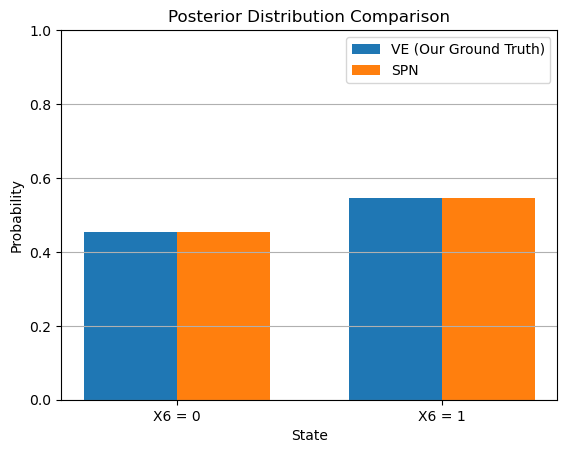

In [19]:
def plot_posterior_comparison(p_ve, p_spn):
    """
    p_ve  : array-like, e.g. [P(X=0), P(X=1)]
    p_spn : array-like, same ordering
    """

    labels = ["X6 = 0", "X6 = 1"]
    x = np.arange(len(labels))
    width = 0.35

    plt.figure()

    plt.bar(x - width/2, p_ve, width, label="VE (Our Ground Truth)")
    plt.bar(x + width/2, p_spn, width, label="SPN")

    plt.ylabel("Probability")
    plt.xlabel("State")
    plt.title("Posterior Distribution Comparison")
    plt.xticks(x, labels)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis="y")

    plt.show()

# VE posterior
p_ve = np.array([prob_ve[0], prob_ve[1]])

# SPN posterior
p_spn = np.array([float(prob_spn[0]), float(prob_spn[1])])

plot_posterior_comparison(p_ve, p_spn)

# SPN with MCD

MCD

Conditional Probability

In [20]:
def mc_dropout_conditional_prob(spn, x_features, label_index, dropout_rate=0.2, samples=50):
    """
    Computes P(y=1 | x) using MC Dropout across multiple forward passes.
    x_features: 1D array of features (29 columns)
    """
    sum_nodes = get_nodes_by_type(spn, Sum)
    all_p_y1 = []

    for _ in range(samples):
        # 1. Apply Dropout Mask
        backup_weights = {}
        for s in sum_nodes:
            mask = np.random.rand(len(s.children)) > dropout_rate
            if not np.any(mask):
                mask[np.random.randint(0, len(mask))] = True
            
            backup_weights[s] = s.weights.copy()
            new_w = s.weights * mask
            s.weights = new_w / np.sum(new_w)

        # 2. Setup evidence for both classes (y=0 and y=1)
        # We create 30-column rows
        row_y0 = np.append(x_features, 0).reshape(1, -1)
        row_y1 = np.append(x_features, 1).reshape(1, -1)

        # 3. Compute Log-Likelihoods for this 'dropped' version of the SPN
        ll_y0 = log_likelihood(spn, row_y0)[0][0]
        ll_y1 = log_likelihood(spn, row_y1)[0][0]

        # 4. Convert to Conditional Probability: P(y=1 | x) = exp(ll_y1) / (exp(ll_y1) + exp(ll_y0))
        # Using the log-sum-exp trick for stability
        max_ll = max(ll_y0, ll_y1)
        p_y1 = np.exp(ll_y1 - max_ll) / (np.exp(ll_y1 - max_ll) + np.exp(ll_y0 - max_ll))
        
        all_p_y1.append(p_y1)

        # 5. Restore Weights
        for s, old in backup_weights.items():
            s.weights = old

    all_p_y1 = np.array(all_p_y1)
    
    # Return the mean prediction and the variance (uncertainty)
    return all_p_y1.mean(), all_p_y1.var(), all_p_y1

# Select a patient (features only - 29 columns)
patient_x = X_test[patient_index] 

# Run MCD Conditional Probability
mean_prob, var_prob, samples_mcd = mc_dropout_conditional_prob(spn, patient_x, label_index=29, dropout_rate=0.3, samples=2000)

#print(f"Mean P(Lung Cancer): {mean_prob:.4f}")
print(f"Uncertainty (Var):   {var_prob:.6f}")
p1_mcd = mean_prob
# p0_mcd is the complement (Probability of Class 0)
p0_mcd = 1.0 - mean_prob

# Now your existing line will work
prob_mcd = np.array([float(p0_mcd), float(p1_mcd)])  

print(f"P(Lung Cancer = 0 | Evidence): {prob_mcd[0]:.4f}")
print(f"P(Lung Cancer = 1 | Evidence): {prob_mcd[1]:.4f}")

Uncertainty (Var):   0.000241
P(Lung Cancer = 0 | Evidence): 0.4650
P(Lung Cancer = 1 | Evidence): 0.5350


In [21]:
print(p1_mcd, p0_mcd)

0.5349927963472698 0.4650072036527302


In [22]:
def predictive_entropy_binary(p1_mean, eps=1e-12):
    """
    Predictive entropy for binary classification
    H = -p log p - (1-p) log(1-p)
    """
    p1 = np.clip(p1_mean, eps, 1 - eps)
    p0 = 1.0 - p1
    return -(p1 * np.log(p1) + p0 * np.log(p0))

# Predictive entropy
entropy_mcd = predictive_entropy_binary(mean_prob)

def entropy_of_samples(samples, eps=1e-12):
    samples = np.clip(samples, eps, 1 - eps)
    return -(samples*np.log(samples) + (1-samples)*np.log(1-samples))

# Expected entropy
expected_entropy = entropy_of_samples(samples_mcd).mean()

# Predictive entropy (already computed)
predictive_ent = predictive_entropy_binary(mean_prob)

# Mutual Information
mutual_information = predictive_ent - expected_entropy

print(f"Predictive Entropy (MCD): {entropy_mcd:.6f}")
print(f"Expected Entropy: {expected_entropy:.6f}")
print(f"Mutual Information (Epistemic): {mutual_information:.6f}")


Predictive Entropy (MCD): 0.690696
Expected Entropy: 0.690212
Mutual Information (Epistemic): 0.000484


Visual Analytics

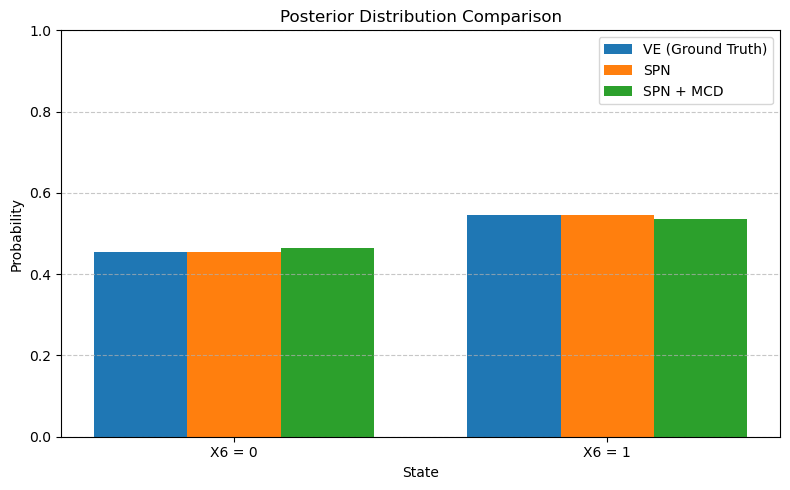

In [23]:
def plot_posterior_comparison_with_mcd(p_ve, p_spn, p_mcd):
    """
    p_ve  : [P(X=0), P(X=1)] from Variable Elimination
    p_spn : deterministic SPN posterior
    p_mcd : Monte Carlo Dropout posterior mean
    """

    labels = ["X6 = 0", "X6 = 1"]
    x = np.arange(len(labels))
    width = 0.25

    plt.figure(figsize=(8, 5))

    plt.bar(x - width, p_ve, width, label="VE (Ground Truth)")
    plt.bar(x,         p_spn, width, label="SPN")
    plt.bar(x + width, p_mcd, width, label="SPN + MCD")

    plt.ylabel("Probability")
    plt.xlabel("State")
    plt.title("Posterior Distribution Comparison")
    plt.xticks(x, labels)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

p1_mcd = mean_prob
# p0_mcd is the complement (Probability of Class 0)
p0_mcd = 1.0 - mean_prob

# Now your existing line will work
p_mcd = np.array([float(p0_mcd), float(p1_mcd)])  
plot_posterior_comparison_with_mcd(p_ve, p_spn, p_mcd)

# SPN + Bayesian Improvements

Creating the SPN with Bayesian Leaves First

In [24]:
def update_gaussian_em(node, data, resp):
    """
    EM M-step update for Gaussian leaves
    """
    col = int(node.scope[0])
    x = data[:, col]
    w = resp

    w_sum = np.sum(w) + 1e-9  # avoid division by zero
    mean = np.sum(w * x) / w_sum
    var = np.sum(w * (x - mean) ** 2) / w_sum

    node.mean = mean
    node.stdev = np.sqrt(max(var, 1e-6))


def compute_node_responsibilities(spn, data):
    """
    Returns:
        resp[node.id] -> responsibility vector (N,)
    """
    N = data.shape[0]
    resp = {}

    # Initialize
    for node in get_nodes_by_type(spn):
        resp[node.id] = np.zeros(N)

    # Root gets full responsibility
    root_ll = log_likelihood(spn, data).ravel()
    resp[spn.id] = np.ones(N)

    # Traverse top-down
    nodes = get_nodes_by_type(spn)
    nodes.sort(key=lambda n: len(n.scope), reverse=True)

    for node in nodes:
        r_node = resp[node.id]

        if isinstance(node, Sum):
            child_lls = [
                log_likelihood(ch, data).ravel()
                for ch in node.children
            ]

            weighted = np.vstack([
                np.log(w) + ll
                for w, ll in zip(node.weights, child_lls)
            ])

            log_norm = np.logaddexp.reduce(weighted, axis=0)

            for i, ch in enumerate(node.children):
                resp[ch.id] += r_node * np.exp(
                    weighted[i] - log_norm
                )

        elif isinstance(node, Product):
            for ch in node.children:
                resp[ch.id] += r_node

    return resp


class BayesianCategoricalLeaf(Leaf):
    def __init__(self, scope, alpha_prior, 
                 eta=0.05,                  # ===== FIX 1: tempered learning rate =====
                 target_strength=20.0,      # ===== FIX 2: posterior normalization strength =====
                 spn_mode=False,            # ===== FIX 5: SPN-like inference switch =====
                 freeze=False):             # ===== FIX 4: freeze leaf (for label)
        
        super().__init__(scope=[scope])
        self.alpha_prior = np.asarray(alpha_prior, dtype=float)
        self.alpha = self.alpha_prior.copy()
        self.eta = eta
        self.target_strength = target_strength
        self.spn_mode = spn_mode
        self.freeze = freeze

    def reset(self):
        self.alpha = self.alpha_prior.copy()

    # ===== FIX 2 helper =====
    def normalize_alpha(self):
        self.alpha = self.target_strength * self.alpha / self.alpha.sum()

    # ===== FIX 1 + FIX 4 + FIX 2 =====
    def em_update(self, data, resp):
        # ===== FIX 4: freeze label leaf =====
        if self.freeze:
            return

        col = self.scope[0]

        for k in range(len(self.alpha)):
            # ===== FIX 1: tempered Bayesian update =====
            self.alpha[k] += self.eta * np.sum(resp[data[:, col] == k])

        # ===== FIX 2: cap posterior strength =====
        self.normalize_alpha()

    # ===== FIX 5: SPN-like inference option =====
    def marginal_prob(self, value):
        if self.spn_mode:
            # behaves exactly like fixed categorical leaf
            return self.alpha_prior[value] / self.alpha_prior.sum()
        else:
            return self.alpha[value] / self.alpha.sum()


def bayesian_cat_eval(node, data=None, **kwargs):
    col = int(node.scope[0])
    out = np.ones((data.shape[0], 1))

    for i in range(data.shape[0]):
        x = data[i, col]
        if not np.isnan(x):
            out[i, 0] = node.marginal_prob(int(x))

    return out


def bayesian_cat_log_eval(node, data=None, **kwargs):
    return np.log(np.clip(bayesian_cat_eval(node, data), 1e-12, None))


BayesianCategoricalLeaf._is_leaf = True
BayesianCategoricalLeaf._eval_func = [bayesian_cat_eval]
BayesianCategoricalLeaf._log_eval_func = [bayesian_cat_log_eval]

def bayesian_bool_leaf(i, p=0.5, strength=50.0):   # ===== FIX 3: strong priors =====
    alpha = [
        (1 - p) * strength,
        p * strength
    ]
    return BayesianCategoricalLeaf(scope=i, alpha_prior=alpha, eta=0.05, target_strength=20.0, spn_mode=False, freeze=False)

def build_bayesian_spn(n_features, discrete_features, seed=None):
    rng = np.random.default_rng(seed)

    def make_feature_branch():
        def make_leaf(i):
            if i == label_index:
                return BayesianCategoricalLeaf(
                    scope=i,
                    alpha_prior=[1.0, 1.0],
                    eta=0.0,                 
                    target_strength=2.0,
                    spn_mode=False,
                    freeze=True    
                )
        
            # ===== discrete features =====
            if i in discrete_features:
                p_start = rng.uniform(0.45, 0.55)
        
                # ===== FIX 3: strong priors =====
                strength = 100.0
        
                alpha = [(1 - p_start) * strength, p_start * strength]
        
                return BayesianCategoricalLeaf(
                    scope=i,
                    alpha_prior=alpha,
                    eta=0.05,                  # FIX 1
                    target_strength=20.0,      # FIX 2
                    spn_mode=False,            # FIX 5 (True = exact SPN behavior)
                    freeze=False
                )
        
            # Gaussian stays unchanged
            return Gaussian(mean=rng.normal(0, 0.01), stdev=1.0, scope=i)

            
        leaves = [make_leaf(i) for i in range(n_features)]

        groups = []
        for i in range(0, n_features, 2):
            if i + 1 >= n_features:
                break

            g1 = Product(children=[leaves[i], leaves[i + 1]])
            g2 = Product(children=[make_leaf(i), make_leaf(i + 1)])
            groups.append((g1, g2))

        mixtures = []
        for g1, g2 in groups:
            w = rng.uniform(0.4, 0.6, size=2)
            w /= w.sum()
            mixtures.append(Sum(children=[g1, g2], weights=w.tolist()))

        return Product(children=mixtures)

    branch_1 = make_feature_branch()
    branch_2 = make_feature_branch()

    top = Sum(children=[branch_1, branch_2], weights=[0.5, 0.5])

    assign_ids(top)
    rebuild_scopes_bottom_up(top)

    print("Bayesian SPN built successfully")
    print(f"Variables: {n_features}")
    print(f"Total Nodes: {len(get_nodes_by_type(top))}")

    return top


In [25]:
label_index = Xy_train.shape[1] - 1
discrete_feats = discrete_features + [label_index]
bayespn = build_bayesian_spn(n_features=Xy_train.shape[1], discrete_features=discrete_feats, seed=myseed)

Bayesian SPN built successfully
Variables: 30
Total Nodes: 213


Training

In [26]:
def em_train_bayesian_spn(spn, data, n_iters=20):
    for it in range(n_iters):
        # ---------- E-step ----------
        lls = log_likelihood(spn, data)
        Z = np.exp(lls - lls.max())  # numerical stability

        # Node responsibilities
        node_resp = compute_node_responsibilities(spn, data)

        # ---------- M-step ----------
        # Reset Bayesian leaves
        for node in get_nodes_by_type(spn, BayesianCategoricalLeaf):
            node.reset()

        # Update leaves
        for node in get_nodes_by_type(spn, BayesianCategoricalLeaf):
            r = node_resp[node.id]
            node.em_update(data, r)

        # Update Gaussians
        for node in get_nodes_by_type(spn, Gaussian):
            update_gaussian_em(node, data, node_resp[node.id])

        # Update Sum weights
        for node in get_nodes_by_type(spn, Sum):
            w = np.array([
                node_resp[ch.id].sum()
                for ch in node.children
            ])
            node.weights = (w / w.sum()).tolist()

        print(f"EM iter {it+1}, avg LL = {lls.mean():.4f}")


In [27]:
em_train_bayesian_spn(bayespn, Xy_train, n_iters=epochs)

EM iter 1, avg LL = -13.7524
EM iter 2, avg LL = -12.8944
EM iter 3, avg LL = -12.8227
EM iter 4, avg LL = -11.7887
EM iter 5, avg LL = -9.3129
EM iter 6, avg LL = -8.7454
EM iter 7, avg LL = -7.5623
EM iter 8, avg LL = -5.4835
EM iter 9, avg LL = -2.9522
EM iter 10, avg LL = -1.2495
EM iter 11, avg LL = -1.2301
EM iter 12, avg LL = -1.2121
EM iter 13, avg LL = -1.1921
EM iter 14, avg LL = -1.1694
EM iter 15, avg LL = -1.1440
EM iter 16, avg LL = -1.1165
EM iter 17, avg LL = -1.0876
EM iter 18, avg LL = -1.0582
EM iter 19, avg LL = -1.0294
EM iter 20, avg LL = -1.0018
EM iter 21, avg LL = -0.9757
EM iter 22, avg LL = -0.9510
EM iter 23, avg LL = -0.9277
EM iter 24, avg LL = -0.9059
EM iter 25, avg LL = -0.8854
EM iter 26, avg LL = -0.8664
EM iter 27, avg LL = -0.8489
EM iter 28, avg LL = -0.8331
EM iter 29, avg LL = -0.8189
EM iter 30, avg LL = -0.8063
EM iter 31, avg LL = -0.7951
EM iter 32, avg LL = -0.7853
EM iter 33, avg LL = -0.7765
EM iter 34, avg LL = -0.7686
EM iter 35, avg LL 

In [28]:
# ==============================
# Select patient 15 as evidence
# ==============================
patient_idx = patient_index

# IMPORTANT: feature-only, 2D shape (1, n_features)
evidence_data = Xy_test[patient_idx:patient_idx + 1].copy()

print("Using patient:", patient_idx)
print("Evidence shape:", evidence_data.shape)

Using patient: 15
Evidence shape: (1, 30)


In [29]:
def temperature_marginalized(spn, evidence, T_mean=1.5, T_std=0.3, samples=500):
    sum_nodes = get_nodes_by_type(spn, Sum)
    p1_samples = []

    for _ in range(samples):
        # Sample temperature
        T = np.random.lognormal(mean=np.log(T_mean), sigma=T_std)

        # Backup and scale Sum weights
        backups = {}
        for s in sum_nodes:
            w = np.asarray(s.weights, dtype=np.float64)
            backups[s] = w.copy()

            w_scaled = w ** (1.0 / T)
            w_scaled /= w_scaled.sum()
            s.weights = w_scaled.tolist()

        # Append label
        Xy0 = np.column_stack([evidence, [[0]]])
        Xy1 = np.column_stack([evidence, [[1]]])

        p0 = likelihood(spn, Xy0)[0]
        p1 = likelihood(spn, Xy1)[0]

        Z = p0 + p1 + 1e-12
        p1_samples.append(p1 / Z)

        # Restore weights
        for s, w_old in backups.items():
            s.weights = w_old.tolist()

    temp_samples = np.asarray(p1_samples)

    return {"mean": float(temp_samples.mean()), "var":  float(temp_samples.var()), "samples": temp_samples}

In [30]:
#For experiment 2
temp_results = temperature_marginalized(spn=bayespn, evidence=evidence_data, T_mean=2.9, T_std=0.8, samples=2000)

p0 = temp_results["mean"]
p1 = 1.0 - p0

samples_temp = temp_results["samples"]

p_temp = np.array([p0, p1])

print("BaySPN + Temperature Marginalization")
print(f"P(Y=0 | X) = {p0:.4f}")
print(f"P(Y=1 | X) = {p1:.4f}")
print(f"Predictive variance = {temp_results['var']:.6f}")


BaySPN + Temperature Marginalization
P(Y=0 | X) = 0.4492
P(Y=1 | X) = 0.5508
Predictive variance = 0.000685


In [31]:
# Mean predictive probability
p1_mean = 1.0 - p0  # same as temp_results["mean"] complement

# Predictive entropy
pred_entropy_bt = predictive_entropy_binary(p1_mean)

# Expected entropy (aleatoric)
expected_entropy_bt = entropy_of_samples(samples_temp).mean()

# Mutual information (epistemic uncertainty)
mutual_info_bt = pred_entropy_bt - expected_entropy_bt

print(f"Predictive Entropy (BayesTemp-SPN): {pred_entropy_bt:.6f}")
print(f"Expected Entropy: {expected_entropy_bt:.6f}")
print(f"Mutual Information (Epistemic): {mutual_info_bt:.6f}")


Predictive Entropy (BayesTemp-SPN): 0.687974
Expected Entropy: 0.686583
Mutual Information (Epistemic): 0.001391


In [32]:
evidence = X_test[idx].reshape(1, -1)

#For experiments 1
upgrade_results = temperature_marginalized(spn=spn, evidence=evidence, T_mean=0.2, T_std=0.09, samples=2000)

p0_upgrade_mean = upgrade_results["mean"]
p0_upgrade_var  = upgrade_results["var"]
samples_upgrade = upgrade_results["samples"]

p1_upgrade_mean = 1.0 - p0_upgrade_mean

upgrade_marg = np.array([p0_upgrade_mean, p1_upgrade_mean])


print("SPN + Bayesian Temperature Scaling")
print(f"P(X6=0 | E) = {p0_upgrade_mean:.4f}")
print(f"P(X6=1 | E) = {p1_upgrade_mean:.4f}")
print(f"Predictive variance = {upgrade_results['var']:.6f}")

SPN + Bayesian Temperature Scaling
P(X6=0 | E) = 0.4486
P(X6=1 | E) = 0.5514
Predictive variance = 0.000010


In [33]:
# Mean predictive probability

# Predictive entropy
pred_entropy_bt = predictive_entropy_binary(p1_upgrade_mean)

# Expected entropy (aleatoric)
expected_entropy_bt = entropy_of_samples(samples_upgrade).mean()

# Mutual information (epistemic uncertainty)
mutual_info_bt = pred_entropy_bt - expected_entropy_bt

print(f"Predictive Entropy (Temp-SPN): {pred_entropy_bt:.6f}")
print(f"Expected Entropy: {expected_entropy_bt:.6f}")
print(f"Mutual Information (Epistemic): {mutual_info_bt:.6f}")


Predictive Entropy (Temp-SPN): 0.687862
Expected Entropy: 0.687842
Mutual Information (Epistemic): 0.000020


# Statistics

Descriptive Statistics

In [79]:
samples_upgrade = 1 - samples_upgrade
samples_temp = 1- samples_temp

In [80]:
# Convert samples to numpy arrays (if they aren't already)
samples_mcd = np.array(samples_mcd)
samples_upgrade = np.array(samples_upgrade)
samples_temp = np.array(samples_temp)

def descriptive_stats(samples):
    stats = {
        "count": len(samples),
        "mean": np.mean(samples),
        "median": np.median(samples),
        "min": np.min(samples),
        "max": np.max(samples),
        "range": np.max(samples) - np.min(samples),
        "Q1": np.percentile(samples, 25),
        "Q3": np.percentile(samples, 75),
        "IQR": np.percentile(samples, 75) - np.percentile(samples, 25),
        "skewness": skew(samples),
        "kurtosis": kurtosis(samples)
    }
    return stats

# Compute statistics for each inference method
stats_mcd = descriptive_stats(samples_mcd)
stats_upgrade = descriptive_stats(samples_upgrade)
stats_temp = descriptive_stats(samples_temp)

In [81]:
stats_mcd

{'count': 2000,
 'mean': np.float64(0.5349927963472698),
 'median': np.float64(0.5448803898766239),
 'min': np.float64(0.5039115339208066),
 'max': np.float64(0.5473692930940721),
 'range': np.float64(0.04345775917326555),
 'Q1': np.float64(0.5309514636369278),
 'Q3': np.float64(0.5448803898766275),
 'IQR': np.float64(0.013928926239699657),
 'skewness': np.float64(-1.1991777713164133),
 'kurtosis': np.float64(-0.2346380893350961)}

In [82]:
stats_upgrade

{'count': 2000,
 'mean': np.float64(0.5513617981666485),
 'median': np.float64(0.5510493703653511),
 'min': np.float64(0.544799662495929),
 'max': np.float64(0.5644107794703546),
 'range': np.float64(0.019611116974425524),
 'Q1': np.float64(0.5490980938553789),
 'Q3': np.float64(0.5531648810343639),
 'IQR': np.float64(0.00406678717898501),
 'skewness': array([0.69850728]),
 'kurtosis': array([0.53934532])}

In [83]:
stats_temp

{'count': 2000,
 'mean': np.float64(0.5508156696429879),
 'median': np.float64(0.5461229518025528),
 'min': np.float64(0.5074071349023765),
 'max': np.float64(0.6532722695315503),
 'range': np.float64(0.14586513462917372),
 'Q1': np.float64(0.5312898721519044),
 'Q3': np.float64(0.5664667090669314),
 'IQR': np.float64(0.03517683691502704),
 'skewness': array([0.80854766]),
 'kurtosis': array([0.46186746])}

In [84]:
# MCD vs Temp-SPN
t1, p1 = stats.ttest_rel(samples_mcd, samples_upgrade)

# Temp-SPN vs BayesTemp-SPN
t2, p2 = stats.ttest_rel(samples_upgrade, samples_temp)

# MCD vs BayesTemp-SPN
t3, p3 = stats.ttest_rel(samples_mcd, samples_temp)

print("MCD vs Temp-SPN:", t1, p1)
print("Temp-SPN vs BayesTemp-SPN:", t2, p2)
print("MCD vs BayesTemp-SPN:", t3, p3)

MCD vs Temp-SPN: [ -56.55393276 -672.13416261 -672.13416144 ... -196.15861724 -672.13416261
 -289.11289273] [0. 0. 0. ... 0. 0. 0.]
Temp-SPN vs BayesTemp-SPN: [0.92726887] [0.35389889]
MCD vs BayesTemp-SPN: [ -5.88637317 -80.11174699 -80.11174685 ... -22.7196134  -80.11174699
 -33.9278451 ] [4.61836039e-009 0.00000000e+000 0.00000000e+000 ... 7.72652101e-102
 0.00000000e+000 1.14051512e-199]


In [85]:
def paired_t_test(x, y):
    """
    Compute paired t-statistic manually and with scipy.
    """
    
    x = np.asarray(x)
    y = np.asarray(y)

    assert len(x) == len(y), "Samples must have equal length"

    n = len(x)

    # Paired differences
    d = x - y

    # Mean difference
    d_bar = np.mean(d)

    # Standard deviation of differences
    sd = np.std(d, ddof=1)

    # Standard error
    se = sd / np.sqrt(n)

    # t statistic
    t_stat = d_bar / se

    # Degrees of freedom
    df = n - 1

    # p value
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

    return {
        "t_statistic": t_stat,
        "p_value": p_value,
        "mean_difference": d_bar,
        "std_difference": sd,
        "n": n
    }

samples_bayes_temp = temp_results["samples"]

result1 = paired_t_test(samples_mcd, samples_upgrade)
result2 = paired_t_test(samples_upgrade, samples_temp)
result3 = paired_t_test(samples_mcd, samples_temp)

print("\nSPN with MCD vs Temp-SPN")
print("t-statistic:", result1["t_statistic"])
print("p-value:", result1["p_value"])

print("\nTemp-SPN vs BayesTemp-SPN")
print("t-statistic:", result2["t_statistic"])
print("p-value:", result2["p_value"])

print("\nSPN with MCD vs BayesTemp-SPN")
print("t-statistic:", result3["t_statistic"])
print("p-value:", result3["p_value"])


SPN with MCD vs Temp-SPN
t-statistic: -46.20195556251169
p-value: 0.0

Temp-SPN vs BayesTemp-SPN
t-statistic: 0.9272688668946659
p-value: 0.3538988944796848

SPN with MCD vs BayesTemp-SPN
t-statistic: -23.249787398107113
p-value: 0.0


# Execution time

def measure_execution_time(func, runs=5):
    times = []

    for _ in range(runs):
        start = time.perf_counter()
        func()
        end = time.perf_counter()

        times.append(end - start)

    times = np.array(times)

    return {
        "mean_time": times.mean(),
        "std_time": times.std(),
        "runs": runs
    }

def run_mcd():
    mc_dropout_conditional_prob(
        spn,
        patient_x,
        label_index=29,
        dropout_rate=0.3,
        samples=2000
    )

mcd_runtime = measure_execution_time(run_mcd, runs=5)
print("MCD-SPN Runtime")
print(f"Mean time: {mcd_runtime['mean_time']:.4f} seconds")
print(f"Std:       {mcd_runtime['std_time']:.4f}")

def run_temp_spn():
    temperature_marginalized(
        spn=spn,
        evidence=evidence,
        T_mean=0.2,
        T_std=0.09,
        samples=2000
    )

temp_runtime = measure_execution_time(run_temp_spn, runs=5)

print("\nTemp-SPN Runtime")
print(f"Mean time: {temp_runtime['mean_time']:.4f} seconds")
print(f"Std:       {temp_runtime['std_time']:.4f}")

def run_bayes_temp():
    temperature_marginalized(
        spn=bayespn,
        evidence=evidence_data,
        T_mean=2.9,
        T_std=0.8,
        samples=2000
    )

bayes_temp_runtime = measure_execution_time(run_bayes_temp, runs=5)

print("\nBayesTemp-SPN Runtime")
print(f"Mean time: {bayes_temp_runtime['mean_time']:.4f} seconds")
print(f"Std:       {bayes_temp_runtime['std_time']:.4f}")

print("\nRuntime per Monte Carlo sample:")

print("MCD-SPN:", mcd_runtime['mean_time'] / samples)
print("Temp-SPN:", temp_runtime['mean_time'] / samples)
print("BayesTemp-SPN:", bayes_temp_runtime['mean_time'] / samples)

In [86]:
def plot_posterior_comparison_with_mcd_and_temp(p_ve, p_spn, p_mcd, p_temp):
    """
    p_ve   : [P(X=0), P(X=1)] from Variable Elimination (ground truth)
    p_spn  : deterministic SPN posterior
    p_mcd  : Monte Carlo Dropout posterior mean
    p_temp : Temperature-scaled SPN posterior
    """

    labels = ["X6 = 0", "X6 = 1"]
    x = np.arange(len(labels))
    width = 0.2

    plt.figure(figsize=(9, 5))

    plt.bar(x - 1.5*width, p_ve,   width, label="VE (Ground Truth)")
    plt.bar(x - 0.5*width, p_spn,  width, label="SPN")
    plt.bar(x + 0.5*width, p_mcd,  width, label="SPN + MCD")
    plt.bar(x + 1.5*width, p_temp, width, label="SPN + Temperature Scaling")

    plt.ylabel("Probability")
    plt.xlabel("State")
    plt.title("Posterior Distribution Comparison")
    plt.xticks(x, labels)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()


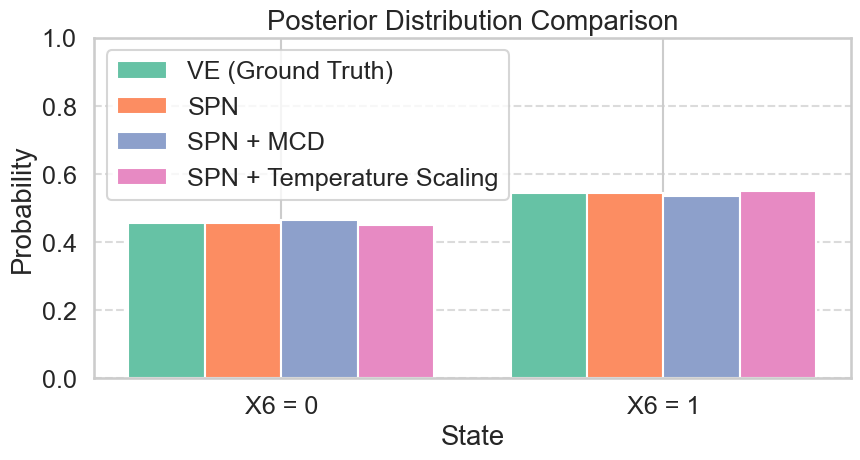

In [87]:
plot_posterior_comparison_with_mcd_and_temp(
    p_ve=p_ve,
    p_spn=p_spn,
    p_mcd=p_mcd,
    p_temp=p_temp
)


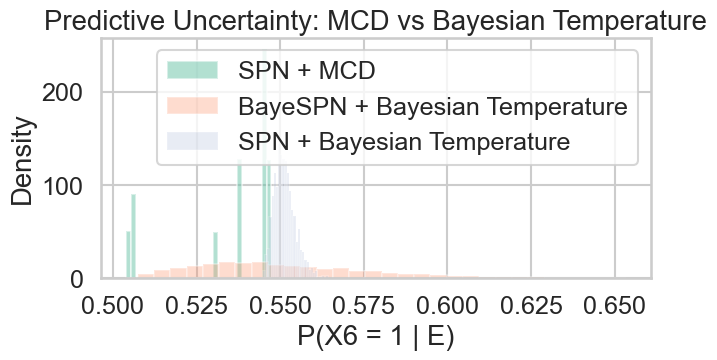

In [88]:
plt.figure(figsize=(7,4))

plt.hist(samples_mcd, bins=30, density=True, alpha=0.5, label="SPN + MCD")
plt.hist(samples_temp, bins=30, density=True, alpha=0.3, label="BayeSPN + Bayesian Temperature")
plt.hist(samples_upgrade, bins=30, density=True, alpha=0.2, label="SPN + Bayesian Temperature")

plt.xlabel("P(X6 = 1 | E)")
plt.ylabel("Density")
plt.title("Predictive Uncertainty: MCD vs Bayesian Temperature")
plt.legend()
plt.tight_layout()
plt.show()


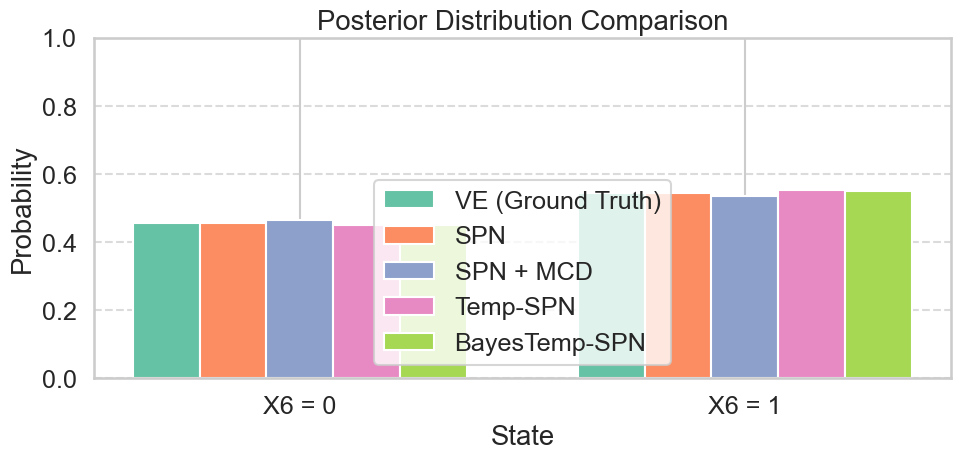

In [89]:
def plot(p_ve, p_spn, p_mcd, upgrade_marg, p_temp):
    """
    p_ve       : [P(X=0), P(X=1)] from Variable Elimination (ground truth)
    p_spn      : deterministic SPN posterior
    p_mcd      : Monte Carlo Dropout posterior mean
    p_temp     : Temperature-scaled SPN posterior
    p_temp_marg: Marginal-temperature-scaled SPN posterior
    """

    labels = ["X6 = 0", "X6 = 1"]
    x = np.arange(len(labels))
    width = 0.15  # narrower to fit 5 bars

    plt.figure(figsize=(10, 5))

    plt.bar(x - 2*width, p_ve,       width, label="VE (Ground Truth)")
    plt.bar(x - width,   p_spn,      width, label="SPN")
    plt.bar(x,           p_mcd,      width, label="SPN + MCD")
    plt.bar(x + width,   upgrade_marg,     width, label="Temp-SPN")
    plt.bar(x + 2*width, p_temp,width, label="BayesTemp-SPN")

    plt.ylabel("Probability")
    plt.xlabel("State")
    plt.title("Posterior Distribution Comparison")
    plt.xticks(x, labels)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

plot(
    p_ve=p_ve,
    p_spn=p_spn,
    p_mcd=p_mcd,
    upgrade_marg=upgrade_marg,
    p_temp=p_temp
)

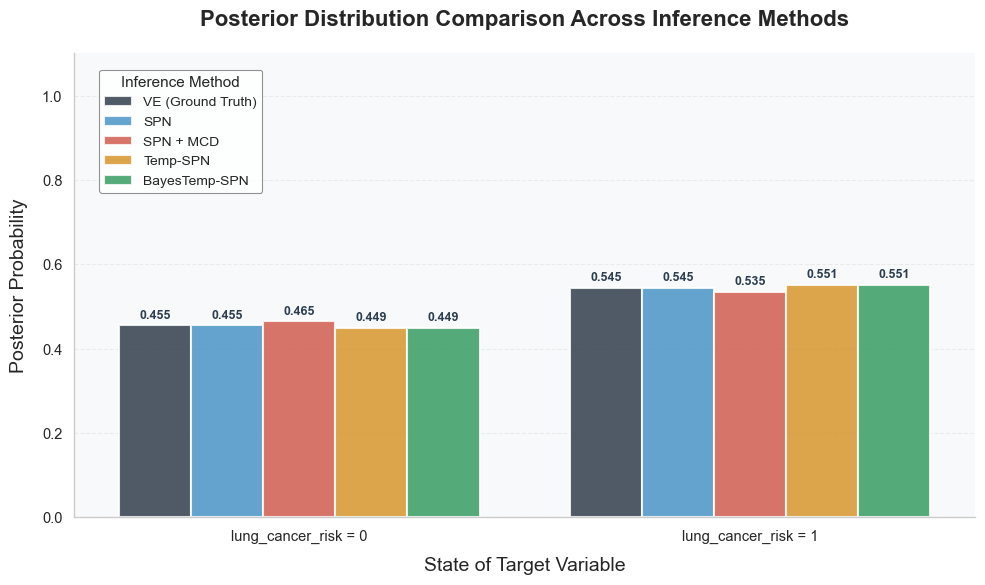

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot(p_ve, p_spn, p_mcd, upgrade_marg, p_temp):
    """
    p_ve       : [P(X=0), P(X=1)] from Variable Elimination (ground truth)
    p_spn      : deterministic SPN posterior
    p_mcd      : Monte Carlo Dropout posterior mean
    upgrade_marg : Temperature-scaled SPN posterior
    p_temp     : BayesTemp-SPN posterior
    """
    
    # Set seaborn style
    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.2)
    
    # Prepare data in tidy format for seaborn
    methods = ["VE (Ground Truth)", "SPN", "SPN + MCD", "Temp-SPN", "BayesTemp-SPN"]
    states = ["lung_cancer_risk = 0", "lung_cancer_risk = 1"]
    
    data = []
    for i, probs in enumerate([p_ve, p_spn, p_mcd, upgrade_marg, p_temp]):
        for j, state in enumerate(states):
            data.append({
                'Method': methods[i],
                'State': state,
                'Probability': probs[j]
            })
    
    df = pd.DataFrame(data)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Custom color palette (colorblind-friendly)
    custom_palette = {
        'VE (Ground Truth)': '#2c3e50',  # Dark blue-gray
        'SPN': '#3498db',                 # Blue
        'SPN + MCD': '#e74c3c',            # Red
        'Temp-SPN': '#f39c12',             # Orange
        'BayesTemp-SPN': '#27ae60'         # Green
    }
    
    # Create grouped bar plot
    bars = sns.barplot(
        data=df,
        x='State',
        y='Probability',
        hue='Method',
        palette=custom_palette,
        edgecolor='white',
        linewidth=1.5,
        alpha=0.85,
        ax=ax
    )
    
    # Add annotations on bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.3f',
            padding=3,
            fontsize=9,
            fontweight='bold',
            color='#2c3e50'
        )
    
    # Customize axes
    ax.set_ylabel('Posterior Probability', fontsize=14, fontweight='medium', labelpad=10)
    ax.set_xlabel('State of Target Variable', fontsize=14, fontweight='medium', labelpad=10)
    ax.set_title('Posterior Distribution Comparison Across Inference Methods',
                 fontsize=16, fontweight='bold', pad=20)
    
    # Set y-axis limits with some padding for annotations
    ax.set_ylim(0, 1.1)
    
    # Customize legend - PLACED INSIDE THE GRAPH
    legend = ax.legend(
        title='Inference Method',
        title_fontsize=11,
        fontsize=10,
        loc='upper left',  # Position in top left
        bbox_to_anchor=(0.02, 0.98),  # Slight offset from corner
        frameon=True,
        framealpha=0.9,
        edgecolor='gray',
        fancybox=True,
        ncol=1,  # Single column
        borderaxespad=0.5
    )
    
    # Optional: Add a semi-transparent background to legend
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.85)
    
    # Customize grid
    ax.grid(True, axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.grid(False, axis='x')
    
    # Remove top and right spines
    sns.despine()
    
    # Add subtle background
    ax.set_facecolor('#f8f9fa')
    
    # Adjust layout (removed the rect parameter that was reserving space for external legend)
    plt.tight_layout()
    
    # Save figure
    plt.savefig('trained_probability.pdf', format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Call the function
plot(
    p_ve=p_ve,
    p_spn=p_spn,
    p_mcd=p_mcd,
    upgrade_marg=upgrade_marg,
    p_temp=p_temp
)

C:\Users\admin_mbmaseko\AppData\Local\Temp\ipykernel_14708\1934721471.py:59: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 0.8, 1])
C:\Users\admin_mbmaseko\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


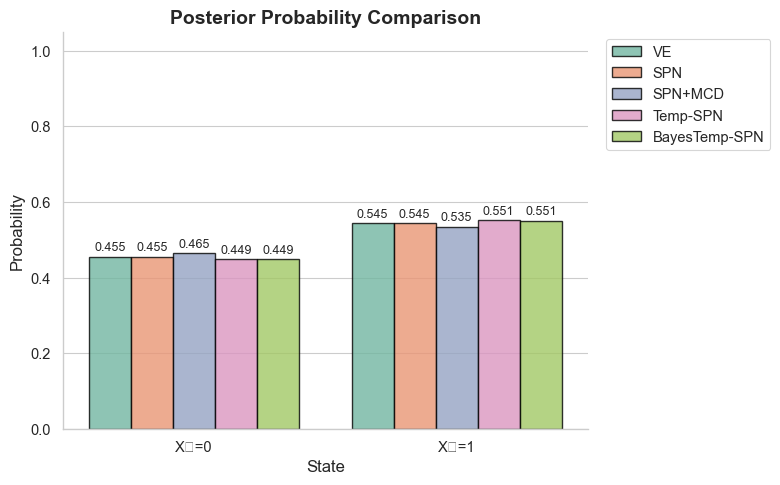

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_compact(p_ve, p_spn, p_mcd, upgrade_marg, p_temp):
    """
    Compact version with clean styling
    """
    
    # Set style
    sns.set_style("whitegrid")
    sns.set_palette("Set2")
    
    # Prepare data
    methods = ["VE", "SPN", "SPN+MCD", "Temp-SPN", "BayesTemp-SPN"]
    states = ["X₆=0", "X₆=1"]
    
    data = []
    for i, probs in enumerate([p_ve, p_spn, p_mcd, upgrade_marg, p_temp]):
        for j, state in enumerate(states):
            data.append({
                'Method': methods[i],
                'State': state,
                'Probability': probs[j]
            })
    
    df = pd.DataFrame(data)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Create plot
    bars = sns.barplot(
        data=df,
        x='State',
        y='Probability',
        hue='Method',
        edgecolor='black',
        linewidth=1,
        alpha=0.8,
        ax=ax
    )
    
    # Annotate bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=2, fontsize=9)
    
    # Customize
    ax.set_ylabel('Probability', fontsize=12)
    ax.set_xlabel('State', fontsize=12)
    ax.set_title('Posterior Probability Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.05)
    
    # Legend outside
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    
    sns.despine()
    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()

# Call the function
plot_compact(
    p_ve=p_ve,
    p_spn=p_spn,
    p_mcd=p_mcd,
    upgrade_marg=upgrade_marg,
    p_temp=p_temp
)

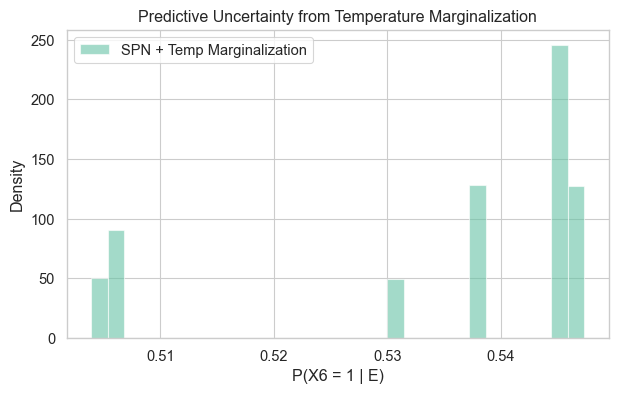

In [92]:
plt.figure(figsize=(7,4))

plt.hist(
    samples_mcd,
    bins=30,
    density=True,
    alpha=0.6,
    label="SPN + Temp Marginalization"
)

plt.xlabel("P(X6 = 1 | E)")
plt.ylabel("Density")
plt.title("Predictive Uncertainty from Temperature Marginalization")
plt.legend()
plt.show()


plt.figure(figsize=(5,4))
plt.bar(
    ["SPN + MCD", "SPN + Bayesian Temp"],
    [np.var(mcd_samples), p1_temp_var]
)
plt.ylabel("Predictive Variance")
plt.title("Uncertainty Magnitude Comparison")
plt.grid(axis="y", alpha=0.3)
plt.show()


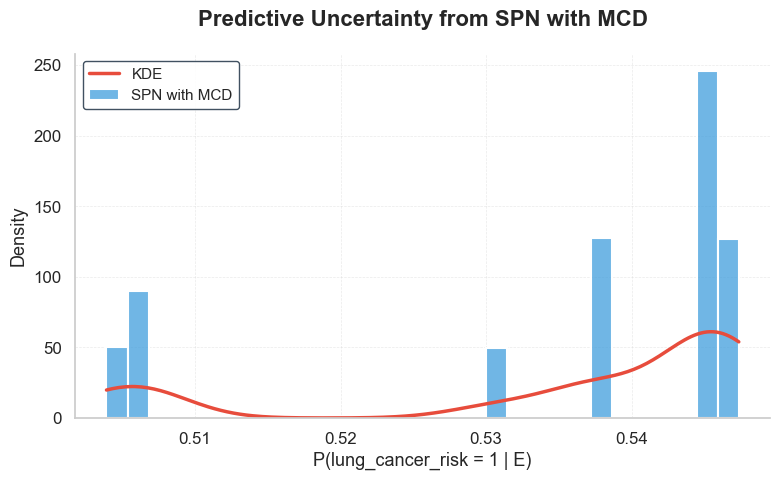

In [93]:
# Set style for better aesthetics
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Create figure with appropriate size
plt.figure(figsize=(8, 5))

# Create the histogram using seaborn
ax = sns.histplot(
    data=samples_mcd,
    bins=30,
    kde=True,  # Adds kernel density estimation line
    stat="density",
    color="#3498db",  # Attractive blue color
    edgecolor="white",
    linewidth=1.5,
    alpha=0.7,
    label="SPN with MCD"
)

# Customize the KDE line for better visibility
if ax.lines:  # Check if KDE line exists
    ax.lines[0].set_color('#e74c3c')  # Red color for KDE
    ax.lines[0].set_linewidth(2.5)
    ax.lines[0].set_linestyle('-')
    ax.lines[0].set_label("KDE")

# Add styling elements
plt.xlabel("P(lung_cancer_risk = 1 | E)", fontsize=13, fontweight='medium')
plt.ylabel("Density", fontsize=13, fontweight='medium')
plt.title("Predictive Uncertainty from SPN with MCD", 
          fontsize=16, 
          fontweight='bold',
          pad=20)

# Customize legend
plt.legend(
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor='#2c3e50',
    loc='best'
)

# Add grid for better readability (seaborn already provides whitegrid)
plt.grid(True, alpha=0.4, linestyle='--', linewidth=0.5)

# Remove top and right spines for cleaner look
sns.despine(left=False, bottom=False)

# Adjust layout
plt.tight_layout()

#plt.savefig("mcd_uncertainty.svg")
plt.savefig("mcd_uncertainty.pdf", format="pdf", bbox_inches="tight")
# Show plot
plt.show()

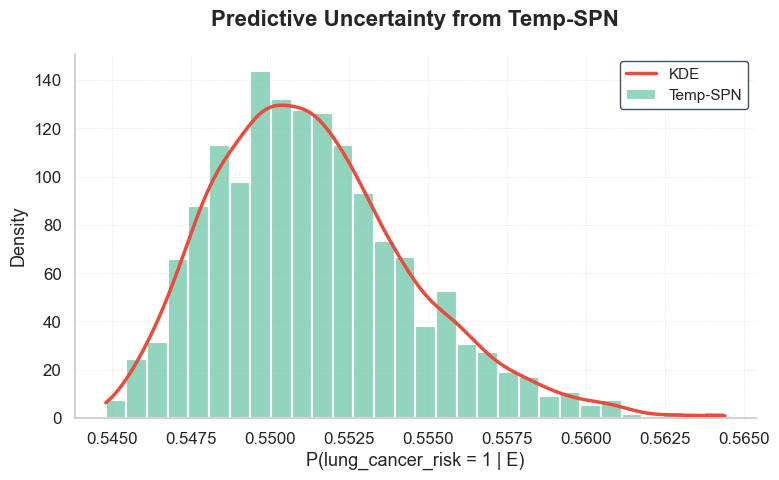

In [94]:
# Set style for better aesthetics
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Create figure with appropriate size
plt.figure(figsize=(8, 5))

# Create the histogram using seaborn
ax = sns.histplot(
    data=samples_upgrade,
    bins=30,
    kde=True,  # Adds kernel density estimation line
    stat="density",
    color="#3498db",  # Attractive blue color
    edgecolor="white",
    linewidth=1.5,
    alpha=0.7,
    label="Temp-SPN"
)

# Customize the KDE line for better visibility
if ax.lines:  # Check if KDE line exists
    ax.lines[0].set_color('#e74c3c')  # Red color for KDE
    ax.lines[0].set_linewidth(2.5)
    ax.lines[0].set_linestyle('-')
    ax.lines[0].set_label("KDE")

# Add styling elements
plt.xlabel("P(lung_cancer_risk = 1 | E)", fontsize=13, fontweight='medium')
plt.ylabel("Density", fontsize=13, fontweight='medium')
plt.title("Predictive Uncertainty from Temp-SPN", 
          fontsize=16, 
          fontweight='bold',
          pad=20)

# Customize legend
plt.legend(
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor='#2c3e50',
    loc='best'
)

# Add grid for better readability (seaborn already provides whitegrid)
plt.grid(True, alpha=0.4, linestyle='--', linewidth=0.5)

# Remove top and right spines for cleaner look
sns.despine(left=False, bottom=False)

# Adjust layout
plt.tight_layout()

#plt.savefig("mcd_uncertainty.svg")
plt.savefig("upgrade_uncertainty.pdf", format="pdf", bbox_inches="tight")
# Show plot
plt.show()

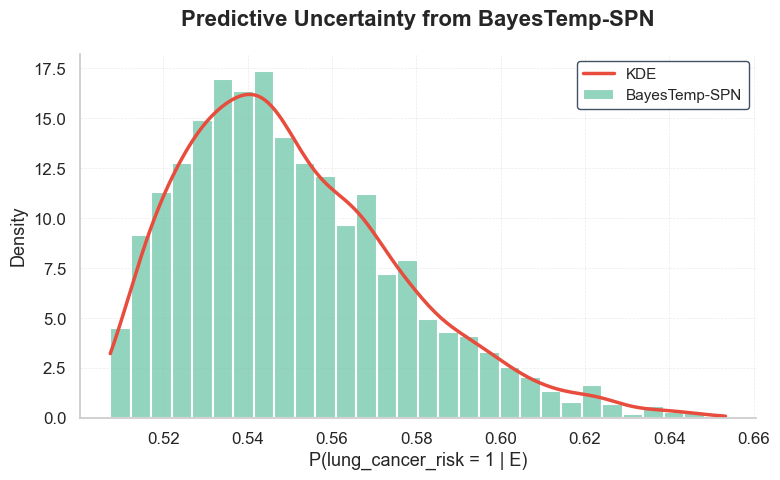

In [95]:
# Set style for better aesthetics
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Create figure with appropriate size
plt.figure(figsize=(8, 5))

# Create the histogram using seaborn
ax = sns.histplot(
    data=samples_temp,
    bins=30,
    kde=True,  # Adds kernel density estimation line
    stat="density",
    color="#3498db",  # Attractive blue color
    edgecolor="white",
    linewidth=1.5,
    alpha=0.7,
    label="BayesTemp-SPN"
)

# Customize the KDE line for better visibility
if ax.lines:  # Check if KDE line exists
    ax.lines[0].set_color('#e74c3c')  # Red color for KDE
    ax.lines[0].set_linewidth(2.5)
    ax.lines[0].set_linestyle('-')
    ax.lines[0].set_label("KDE")

# Add styling elements
plt.xlabel("P(lung_cancer_risk = 1 | E)", fontsize=13, fontweight='medium')
plt.ylabel("Density", fontsize=13, fontweight='medium')
plt.title("Predictive Uncertainty from BayesTemp-SPN", 
          fontsize=16, 
          fontweight='bold',
          pad=20)

# Customize legend
plt.legend(
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor='#2c3e50',
    loc='best'
)

# Add grid for better readability (seaborn already provides whitegrid)
plt.grid(True, alpha=0.4, linestyle='--', linewidth=0.5)

# Remove top and right spines for cleaner look
sns.despine(left=False, bottom=False)

# Adjust layout
plt.tight_layout()

#plt.savefig("mcd_uncertainty.svg")
plt.savefig("BayesTemp_uncertainty.pdf", format="pdf", bbox_inches="tight")
# Show plot
plt.show()

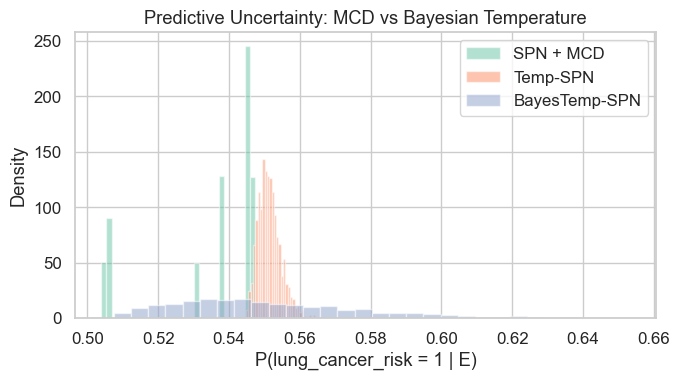

In [96]:
plt.figure(figsize=(7,4))

plt.hist(samples_mcd, bins=30, density=True, alpha=0.5, label="SPN + MCD")
plt.hist(samples_upgrade, bins=30, density=True, alpha=0.5,label="Temp-SPN")
plt.hist(samples_temp, bins=30, density=True, alpha=0.5,label="BayesTemp-SPN")

plt.xlabel("P(lung_cancer_risk = 1 | E)")
plt.ylabel("Density")
plt.title("Predictive Uncertainty: MCD vs Bayesian Temperature")
plt.legend()
plt.tight_layout()
plt.show()


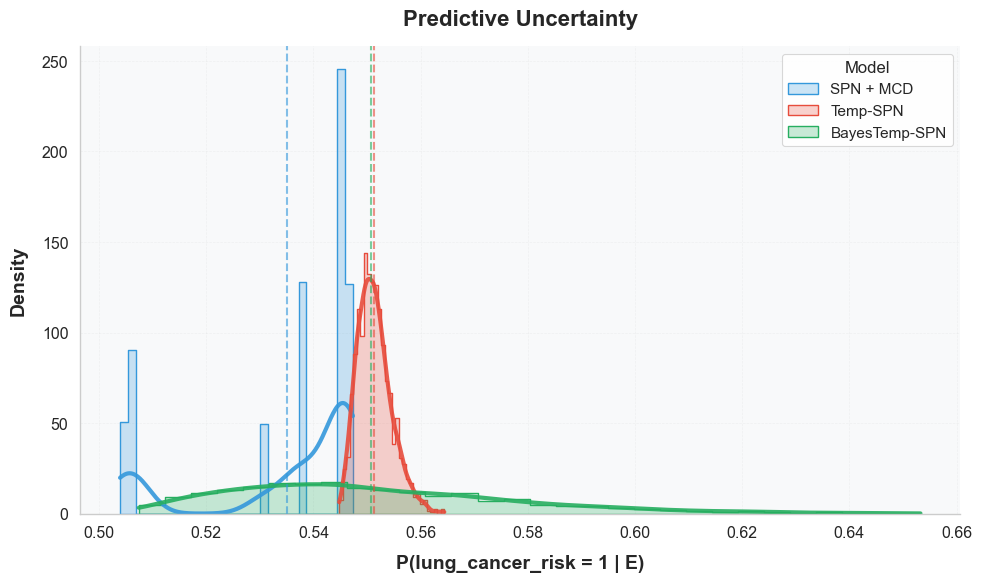

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set beautiful seaborn style
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.3)

# Create figure - SINGLE PLOT ONLY
fig, ax_main = plt.subplots(figsize=(10, 6))

# Prepare data in tidy format
samples_list = [samples_mcd, samples_upgrade, samples_temp]
labels_list = ['SPN + MCD', 'Temp-SPN', 'BayesTemp-SPN']
colors_list = ['#3498db', '#e74c3c', '#27ae60']  # Blue, Red, Green

# ------------------------------------------------------------
# MAIN PLOT: Histogram with KDE
# ------------------------------------------------------------

# Create histogram with KDE
for samples, label, color in zip(samples_list, labels_list, colors_list):
    samples_flat = np.asarray(samples).flatten()
    
    # Histogram
    sns.histplot(
        samples_flat,
        bins=30,
        stat='density',
        kde=True,
        color=color,
        alpha=0.25,  # Very transparent fill
        edgecolor=color,
        linewidth=1,
        label=label,
        ax=ax_main,
        element='step',  # Clean step histogram
        fill=True
    )

# Enhance KDE lines (make them more visible)
for line in ax_main.lines[-3:]:  # Get the last 3 lines (KDEs)
    line.set_linewidth(3)
    line.set_alpha(0.9)

# Add vertical lines for means (optional - remove if you want even cleaner)
for samples, color in zip(samples_list, colors_list):
    samples_flat = np.asarray(samples).flatten()
    mean_val = np.mean(samples_flat)
    ax_main.axvline(
        x=mean_val, 
        color=color, 
        linestyle='--', 
        linewidth=1.5, 
        alpha=0.6
    )

# Customize main plot
ax_main.set_xlabel('P(lung_cancer_risk = 1 | E)', fontsize=14, fontweight='semibold', labelpad=10)
ax_main.set_ylabel('Density', fontsize=14, fontweight='semibold', labelpad=10)
ax_main.set_title('Predictive Uncertainty',
                  fontsize=16, fontweight='bold', pad=15)

# Customize grid - lighter and less intrusive
ax_main.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)

# Customize legend - clean and simple
legend = ax_main.legend(
    fontsize=11,
    title='Model',
    title_fontsize=12,
    loc='upper right',
    frameon=True,
    framealpha=0.9,
    edgecolor='lightgray',
    fancybox=True
)
legend.get_frame().set_facecolor('white')

# Remove top and right spines
sns.despine(ax=ax_main)

# Add very subtle background color
ax_main.set_facecolor('#f8f9fa')

# Set x-axis limits with a little padding
x_min = min([np.min(samples) for samples in samples_list])
x_max = max([np.max(samples) for samples in samples_list])
padding = (x_max - x_min) * 0.05
ax_main.set_xlim(x_min - padding, x_max + padding)

# Adjust layout
plt.tight_layout()

# Save high-quality figures
plt.savefig('predictive_uncertainty_clean.pdf', format='pdf', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()

C:\Users\admin_mbmaseko\AppData\Local\Temp\ipykernel_14708\1853541789.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


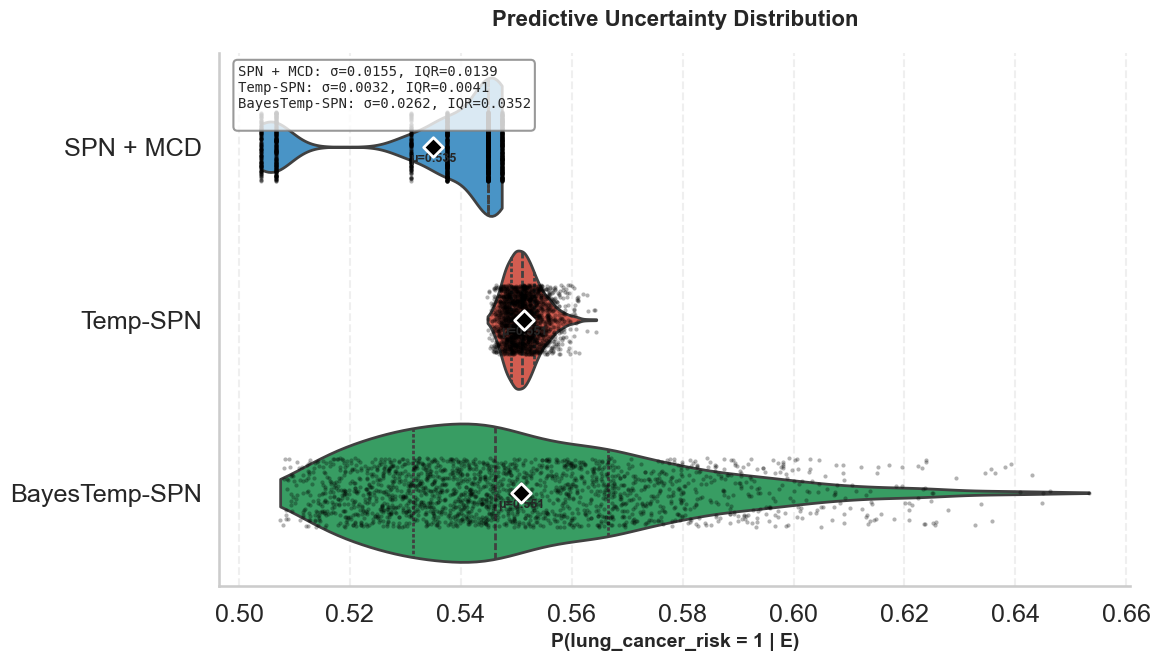

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Set style
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.1)

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data
samples_list = [samples_mcd, samples_upgrade, samples_temp]
labels_list = ['SPN + MCD', 'Temp-SPN', 'BayesTemp-SPN']
colors_list = ['#3498db', '#e74c3c', '#27ae60']
markers_list = ['o', 's', '^']

data = []
for samples, label in zip(samples_list, labels_list):
    samples_flat = np.asarray(samples).flatten()
    for val in samples_flat:
        data.append({'Model': label, 'Probability': val})

df = pd.DataFrame(data)

# Create violin plot (shows distribution beautifully)
sns.violinplot(
    data=df,
    x='Probability',
    y='Model',
    palette=colors_list,
    inner='quartile',  # Shows quartiles inside
    linewidth=2,
    saturation=0.75,
    cut=0,  # Truncate at data limits
    ax=ax
)

# Add strip plot for individual points (jittered)
sns.stripplot(
    data=df,
    x='Probability',
    y='Model',
    color='black',
    alpha=0.3,
    size=3,
    jitter=0.2,
    ax=ax
)

# Add vertical line for ground truth if available
# ax.axvline(x=ground_truth, color='red', linestyle='--', 
#            linewidth=2, alpha=0.8, label='Ground Truth')

# Add mean markers
for i, (samples, color) in enumerate(zip(samples_list, colors_list)):
    samples_flat = np.asarray(samples).flatten()
    mean_val = np.mean(samples_flat)
    ax.scatter(mean_val, i, color='black', s=100, zorder=10, 
               edgecolor='white', linewidth=2, marker='D')
    ax.text(mean_val, i + 0.1, f'μ={mean_val:.3f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize plot
ax.set_xlabel('P(lung_cancer_risk = 1 | E)', fontsize=14, fontweight='semibold')
ax.set_ylabel('')
ax.set_title('Predictive Uncertainty Distribution',
             fontsize=16, fontweight='bold', pad=20)

# Add statistical annotations
stats_text = ""
for samples, label in zip(samples_list, labels_list):
    samples_flat = np.asarray(samples).flatten()
    stats_text += f"{label}: σ={np.std(samples_flat):.4f}, IQR={np.percentile(samples_flat, 75)-np.percentile(samples_flat, 25):.4f}\n"

bbox_props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', bbox=bbox_props,
        fontfamily='monospace')

# Customize grid
ax.grid(True, alpha=0.3, linestyle='--', axis='x')
ax.grid(False, axis='y')

sns.despine()

plt.tight_layout()
plt.savefig('predictive_uncertainty_violin.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

In [99]:
#Table
def posterior_summary_table(
    p_ve,
    p_spn,
    p_mcd,
    p_temp,
    upgrade_marg
):
    """
    Creates a summary table of posterior probabilities.

    Each input is expected to be:
        [P(X6=0 | E), P(X6=1 | E)]
    """

    data = {
        "Model": [
            "VE (Ground Truth)",
            "SPN",
            "SPN + MCD",
            "Temp-SPN",
            "BayesTemp-SPN"
        ],
        "P(X6 = 0 | E)": [
            p_ve[0],
            p_spn[0],
            p_mcd[0],
            upgrade_marg[0],
            p_temp[0]
            
        ],
        "P(X6 = 1 | E)": [
            p_ve[1],
            p_spn[1],
            p_mcd[1],
            upgrade_marg[1],
            p_temp[1]

        ]
    }

    df = pd.DataFrame(data)

    # Optional formatting for readability
    df["P(X6 = 0 | E)"] = df["P(X6 = 0 | E)"].astype(float)
    df["P(X6 = 1 | E)"] = df["P(X6 = 1 | E)"].astype(float)

    return df
summary_df = posterior_summary_table(p_ve=p_ve, p_spn=p_spn, p_mcd=p_mcd, p_temp=p_temp, upgrade_marg=upgrade_marg)
print(summary_df)


               Model  P(X6 = 0 | E)  P(X6 = 1 | E)
0  VE (Ground Truth)       0.455120       0.544880
1                SPN       0.455120       0.544880
2          SPN + MCD       0.465007       0.534993
3           Temp-SPN       0.448638       0.551362
4      BayesTemp-SPN       0.449184       0.550816


Error Calculation

In [100]:
def posterior_mae(p_model, p_ve):
    """
    Mean Absolute Error between two Bernoulli posteriors
    """
    p_model = np.asarray(p_model)
    p_ve = np.asarray(p_ve)
    return np.mean(np.abs(p_model - p_ve))

In [101]:
mcd_mae = posterior_mae(p_mcd, prob_ve)
temp_marg_mae = posterior_mae(p_temp, prob_ve)
upgrade_mae = posterior_mae(upgrade_marg, prob_ve)

print(f"SPN + MCD:")
print(f"  MAE = {mcd_mae:.6f}")

print(f"\nBaySPN + Temperature Marginalization:")
print(f"  MAE = {temp_marg_mae:.6f}")

print(f"\nSPN + Temperature Marginalization:")
print(f"  MAE = {upgrade_mae:.6f}")

SPN + MCD:
  MAE = 0.009888

BaySPN + Temperature Marginalization:
  MAE = 0.005935

SPN + Temperature Marginalization:
  MAE = 0.006481


In [102]:
def samplewise_mae(p1_samples, p_ve):
    """
    Compute MAE per Monte Carlo sample for Bernoulli posterior

    p1_samples : array of P(X6=1 | E) samples
    p_ve       : [P(X6=0), P(X6=1)] from VE
    """
    p0_ve, p1_ve = p_ve

    mae = []
    for p1 in p1_samples:
        p0 = 1.0 - p1
        mae.append(
            0.5 * (abs(p0 - p0_ve) + abs(p1 - p1_ve))
        )

    return np.array(mae)

mae_mcd = samplewise_mae(samples_mcd, p_ve)
mae_temp = samplewise_mae(samples_temp, p_ve)
mae_upgrade = samplewise_mae(samples_upgrade, p_ve)

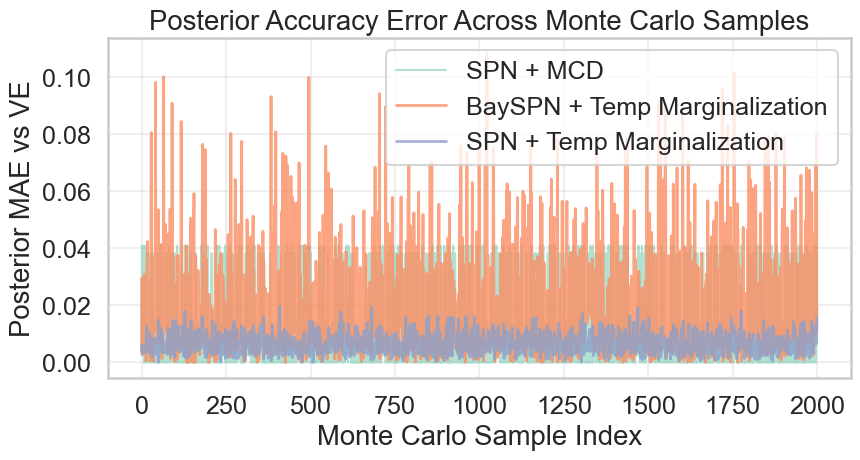

In [103]:
plt.figure(figsize=(9, 5))

plt.plot(
    mae_mcd,
    alpha=0.5,
    label="SPN + MCD",
    linewidth=1.5
)

plt.plot(
    mae_temp,
    alpha=0.8,
    label="BaySPN + Temp Marginalization",
    linewidth=2
)

plt.plot(
    mae_upgrade,
    alpha=0.8,
    label="SPN + Temp Marginalization",
    linewidth=2
)

plt.ylabel("Posterior MAE vs VE")
plt.xlabel("Monte Carlo Sample Index")
plt.title("Posterior Accuracy Error Across Monte Carlo Samples")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


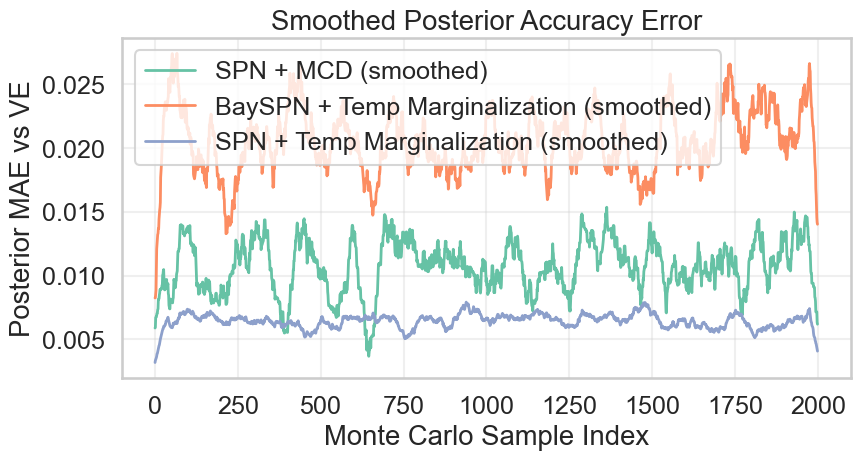

In [104]:
def moving_average(x, w=10):
    """
    Compute moving average of a 1D array.
    
    Args:
        x : array-like
        w : window size
    
    Returns:
        numpy array of same length as input (edges are padded)
    """
    import numpy as np
    x = np.asarray(x)
    if w < 1:
        return x
    return np.convolve(x, np.ones(w)/w, mode='same')


# Ensure 1D
mae_mcd = np.asarray(mae_mcd).reshape(-1)
mae_temp = np.asarray(mae_temp).reshape(-1)
mae_upgrade = np.asarray(mae_upgrade).reshape(-1)

plt.figure(figsize=(9, 5))

plt.plot(
    moving_average(mae_mcd, w=50),
    label="SPN + MCD (smoothed)",
    linewidth=2
)

plt.plot(
    moving_average(mae_temp, w=50),
    label="BaySPN + Temp Marginalization (smoothed)",
    linewidth=2
)

plt.plot(
    moving_average(mae_upgrade, w=50),
    label="SPN + Temp Marginalization (smoothed)",
    linewidth=2
)

plt.ylabel("Posterior MAE vs VE")
plt.xlabel("Monte Carlo Sample Index")
plt.title("Smoothed Posterior Accuracy Error")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [105]:
print("Bias:")
print("MCD:", abs(np.mean(samples_mcd) - p_ve[1]))
print("Temp:", abs(np.mean(samples_temp) - p_ve[1]))
print("Upgrade:", abs(np.mean(samples_upgrade) - p_ve[1]))

print("\nVariance:")
print("MCD:", np.var(samples_mcd))
print("Temp:", np.var(samples_temp))
print("Upgrade:", np.var(samples_upgrade))


Bias:
MCD: 0.00988759349216839
Temp: 0.005935279803549687
Upgrade: 0.006481408327210336

Variance:
MCD: 0.00024108342505992759
Temp: 0.000685239934519787
Upgrade: 9.962724593621768e-06


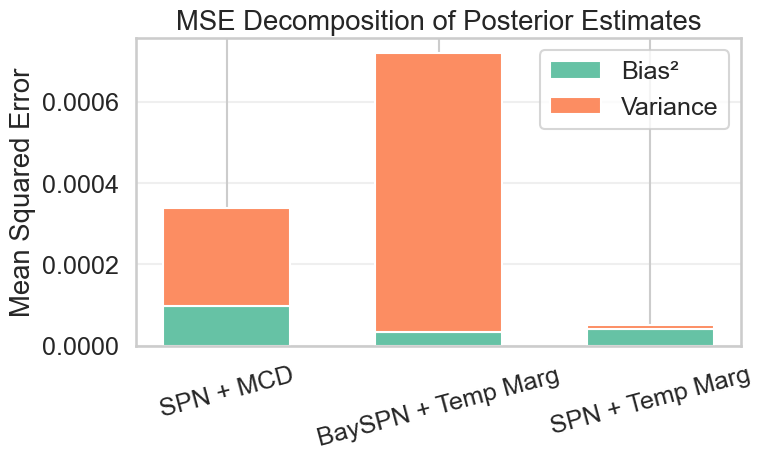

In [106]:
def mse_decomposition(samples, p_true):
    mean_p = np.mean(samples)
    bias2 = (mean_p - p_true) ** 2
    var = np.var(samples)
    mse = bias2 + var
    return bias2, var, mse


models = {
    "SPN + MCD": samples_mcd,
    "BaySPN + Temp Marg": samples_temp,
    "SPN + Temp Marg": samples_upgrade
}

results = {}
for name, samples in models.items():
    results[name] = mse_decomposition(samples, p_ve[1])

import matplotlib.pyplot as plt

labels = list(results.keys())
bias2 = [results[k][0] for k in labels]
var = [results[k][1] for k in labels]

x = np.arange(len(labels))
width = 0.6

plt.figure(figsize=(8, 5))

plt.bar(x, bias2, width, label="Bias²")
plt.bar(x, var, width, bottom=bias2, label="Variance")

plt.xticks(x, labels, rotation=15)
plt.ylabel("Mean Squared Error")
plt.title("MSE Decomposition of Posterior Estimates")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [107]:
def expected_brier(p, p_ve):
    """
    Expected Brier score under VE posterior
    p     : model P(Y=1 | X)
    p_ve  : VE posterior [P0, P1]
    """
    return p_ve[1] * (p - 1)**2 + p_ve[0] * (p - 0)**2

brier_mcd = expected_brier(np.mean(samples_mcd), p_ve)
brier_temp = expected_brier(np.mean(samples_temp), p_ve)
brier_upgrade = expected_brier(np.mean(samples_upgrade), p_ve)

print(f"MCD {brier_mcd}")
print(f"BayeSPN + Temp {brier_temp}")
print(f"SPN + Temp {brier_upgrade}")

MCD 0.24808351511292642
BayeSPN + Temp 0.24802097815420648
SPN + Temp 0.24802775926176407


In [108]:
def samplewise_expected_brier(p_samples, p_ve):
    return p_ve[1] * (p_samples - 1)**2 + p_ve[0] * (p_samples - 0)**2
brier_mcd_samples = samplewise_expected_brier(samples_mcd, p_ve)
brier_temp_samples = samplewise_expected_brier(samples_temp, p_ve)
brier_upgrade_samples = samplewise_expected_brier(samples_upgrade, p_ve)

print(f"MCD {brier_mcd_samples}")
print(f"BayeSPN + Temp {brier_temp_samples}")
print(f"SPN + Temp {brier_upgrade_samples}")

MCD [0.24799195 0.2496642  0.2496642  ... 0.24804002 0.2496642  0.24817977]
BayeSPN + Temp [[0.24799759]
 [0.24886244]
 [0.24799447]
 ...
 [0.24818995]
 [0.2544086 ]
 [0.24809379]]
SPN + Temp [[0.24802556]
 [0.24799997]
 [0.24801896]
 ...
 [0.24805874]
 [0.24803401]
 [0.24823648]]


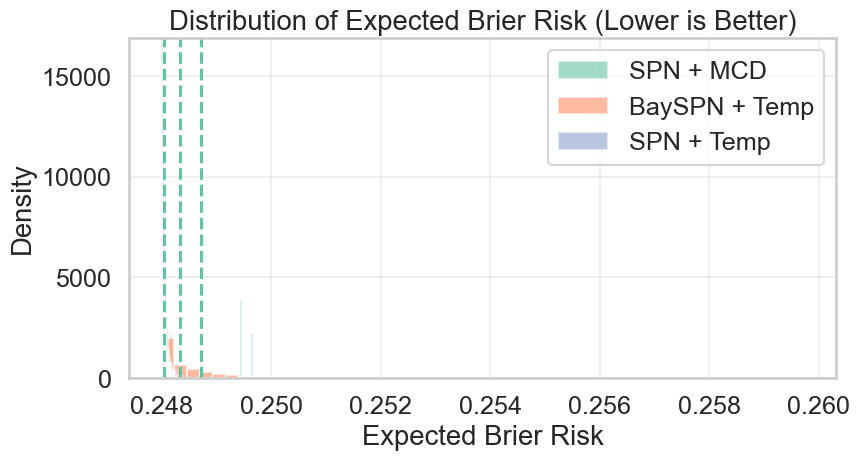

In [109]:
plt.figure(figsize=(9, 5))

plt.hist(
    brier_mcd_samples,
    bins=50,
    density=True,
    alpha=0.6,
    label="SPN + MCD"
)

plt.hist(
    brier_temp_samples,
    bins=50,
    density=True,
    alpha=0.6,
    label="BaySPN + Temp"
)

plt.hist(
    brier_upgrade_samples,
    bins=50,
    density=True,
    alpha=0.6,
    label="SPN + Temp"
)

plt.axvline(np.mean(brier_mcd_samples), linestyle="--")
plt.axvline(np.mean(brier_temp_samples), linestyle="--")
plt.axvline(np.mean(brier_upgrade_samples), linestyle="--")

plt.xlabel("Expected Brier Risk")
plt.ylabel("Density")
plt.title("Distribution of Expected Brier Risk (Lower is Better)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


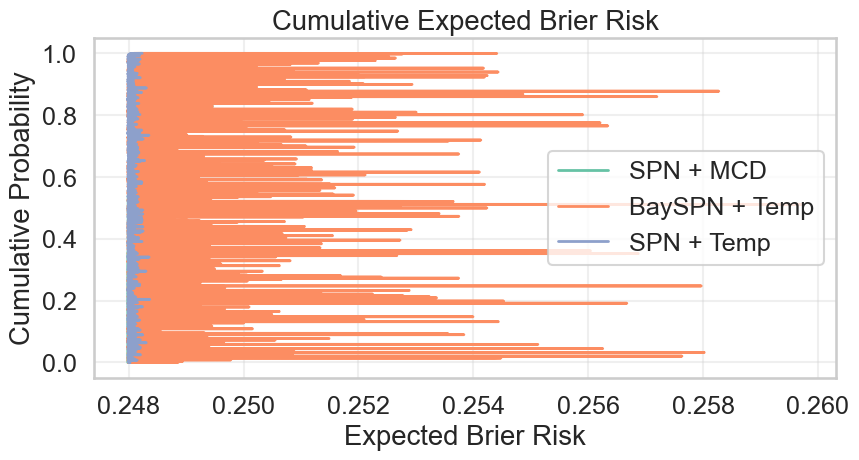

In [110]:
plt.figure(figsize=(9, 5))

for samples, label in [
    (brier_mcd_samples, "SPN + MCD"),
    (brier_temp_samples, "BaySPN + Temp"),
    (brier_upgrade_samples, "SPN + Temp"),
]:
    sorted_samples = np.sort(samples)
    plt.plot(
        sorted_samples,
        np.linspace(0, 1, len(sorted_samples)),
        label=label,
        linewidth=2
    )

plt.xlabel("Expected Brier Risk")
plt.ylabel("Cumulative Probability")
plt.title("Cumulative Expected Brier Risk")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Random Forest

In [111]:
#Create and train RF
from sklearn.calibration import CalibratedClassifierCV
rf = RandomForestClassifier(
    n_estimators=2000,      # number of trees
    max_depth=None,        # allow full tree growth
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=myseed,
    n_jobs=-1              # use all CPU cores
)
rf_cal = CalibratedClassifierCV(rf, method="isotonic", cv=5)
rf.fit(X_train, y_train)
print("Random Forest training completed")

Random Forest training completed


In [112]:
rf_probs = rf.predict_proba(X_test)[:, 1]   # P(Y=1 | X)
rf_preds = rf.predict(X_test)

idx = patient_index

rf_single_prob = rf.predict_proba(X_test[idx].reshape(1,-1))[0]

p_rf_0 = rf_single_prob[0]
p_rf_1 = rf_single_prob[1]

print("\nRandom Forest Prediction")
print(f"P(Y=0 | X) = {p_rf_0:.4f}")
print(f"P(Y=1 | X) = {p_rf_1:.4f}")


Random Forest Prediction
P(Y=0 | X) = 0.0828
P(Y=1 | X) = 0.9172
